In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.optimize import brentq

# 1 Grid and Nozzle Geometry


In [4]:
# Grid and nozzle geometry
N = 300
x = np.linspace(0, 0.075, N)
dx = x[1] - x[0]

# -----------------------------
# 1. CONSTANTS & GRID
# -----------------------------
# ... (keep your gamma, CFL, N, max_iter, x, dx here) ...

# --- CENTRALIZED GEOMETRY DEFINITION ---
 # Throat position in meters
# --- CENTRALIZED GEOMETRY DEFINITION ---
def get_nozzle_area(x_pos):
    """
    Linear Area Nozzle based on Standard Dimensions:
    Length = 75mm, D_in = 25mm, D_t = 10mm, D_out = 35mm
    Calculated to maintain a constant dA/dx derivative.
    """
    x_t = 0.02659 # Throat position in meters

    # Linear Area Coefficients (Constant Slopes)
    # Converging: (6.25 - 1.0) / 0.02659
    C1 = 197.44
    # Diverging: (12.25 - 1.0) / 0.04841
    C2 = 232.39

    return np.where(x_pos <= x_t,
                    1.0 + C1 * np.abs(x_pos - x_t),  # No squares!
                    1.0 + C2 * np.abs(x_pos - x_t))  # No squares!

# Quadratic Nozzle
# def get_nozzle_area(x):
#     x_t = 1.5 # Throat position in meters
#     return 1 + 2.2*(x - x_t)**2

# # Steep Nozzle
# def get_nozzle_area(x):
#     x_t = 0.02659 # Throat position in meters
#     return 1 + 5*(x - x_t)**2

# Generate Cell-Center Areas
A = get_nozzle_area(x)
dAdx = np.gradient(A, x)

# Generate Exact Cell-Face Areas (Much more accurate than averaging!)
x_face = x[:-1] + 0.5 * dx
A_face = get_nozzle_area(x_face)

# 2 LAX FRIEDRICHS SCHEME


## 2.1 Parameters and Initial Conditions

In [5]:
gamma = 1.4
CFL = 0.2
max_iter = 5000

# Inlet total conditions (KEEP SAME FOR ALL RUNS)
p0 = 3e5
T0 = 300.0
R  = 287.0
cp = gamma * R / (gamma - 1)

# Back pressure (CHANGE THIS PER RUN)
p_back = 5e4  # try: 1.1e5, 5e4, 5e3

# ---------------- INITIAL CONDITION ----------------
rho = np.ones(N)
u   = 10 * np.ones(N)
p   = 1e5 * np.ones(N)

E = p/(gamma-1) + 0.5*rho*u**2

U = np.array([
    rho*A,
    rho*u*A,
    E*A
])

## 2.2 Time Marching using RK2

In [6]:
residuals = []

for n in range(max_iter):

    # -------- primitive --------
    rho = U[0]/A
    u   = U[1]/U[0]
    E   = U[2]/A
    p   = (E - 0.5*rho*u**2)*(gamma-1)
    a   = np.sqrt(gamma*p/rho)

    # -------- flux --------
    F = np.array([
        rho*u*A,
        A*(rho*u**2 + p),
        (E+p)*u*A
    ])

    J = np.array([
        np.zeros_like(A),
        p*dAdx,
        np.zeros_like(A)
    ])

    # -------- LF flux --------
    F_half = np.zeros((3, N-1))
    for j in range(3):
        for i in range(N-1):
            alpha = max(abs(u[i])+a[i], abs(u[i+1])+a[i+1])
            F_half[j,i] = 0.5*(F[j,i]+F[j,i+1]) \
                        - 0.5*alpha*(U[j,i+1]-U[j,i])

    # -------- k1 --------
    k1 = np.zeros_like(U)
    for j in range(3):
        for i in range(1,N-1):
            k1[j,i] = -(F_half[j,i]-F_half[j,i-1])/dx + J[j,i]

    dt = CFL * dx / np.max(np.abs(u)+a)

    U_old = U.copy()

    # -------- predictor --------
    U1 = U + dt*k1

    # ==========================
    # INLET BC (TOTAL CONDITIONS)
    # ==========================
    rho1 = U1[0]/A
    u1   = U1[1]/U1[0]

    u_in = u1[1]

    T_in = T0 - u_in**2/(2*cp)
    p_in = p0 * (T_in/T0)**(gamma/(gamma-1))
    rho_in = p_in/(R*T_in)

    E_in = p_in/(gamma-1) + 0.5*rho_in*u_in**2

    U1[0,0] = rho_in*A[0]
    U1[1,0] = rho_in*u_in*A[0]
    U1[2,0] = E_in*A[0]

    # ==========================
    # OUTLET BC
    # ==========================
    rho1 = U1[0]/A
    u1   = U1[1]/U1[0]
    E1   = U1[2]/A
    p1   = (E1 - 0.5*rho1*u1**2)*(gamma-1)

    a_int = np.sqrt(gamma*p1[-2]/rho1[-2])
    M_int = u1[-2]/a_int

    if M_int < 1:
        p_out = p_back
        rho_out = rho1[-2]
        u_out   = u1[-2]
    else:
        p_out = p1[-2]
        rho_out = rho1[-2]
        u_out   = u1[-2]

    E_out = p_out/(gamma-1) + 0.5*rho_out*u_out**2

    U1[0,-1] = rho_out*A[-1]
    U1[1,-1] = rho_out*u_out*A[-1]
    U1[2,-1] = E_out*A[-1]

    # -------- recompute flux --------
    rho = U1[0]/A
    u   = U1[1]/U1[0]
    E   = U1[2]/A
    p   = (E - 0.5*rho*u**2)*(gamma-1)
    a   = np.sqrt(gamma*p/rho)

    F = np.array([
        rho*u*A,
        A*(rho*u**2 + p),
        (E+p)*u*A
    ])

    for j in range(3):
        for i in range(N-1):
            alpha = max(abs(u[i])+a[i], abs(u[i+1])+a[i+1])
            F_half[j,i] = 0.5*(F[j,i]+F[j,i+1]) \
                        - 0.5*alpha*(U1[j,i+1]-U1[j,i])

    k2 = np.zeros_like(U)
    for j in range(3):
        for i in range(1,N-1):
            k2[j,i] = -(F_half[j,i]-F_half[j,i-1])/dx + J[j,i]

    # -------- update --------
    U = 0.5*(U + U1 + dt*k2)

    residual = np.max(np.abs((U-U_old)/(U_old+1e-8)))
    residuals.append(residual)

    if n % 200 == 0:
        print(f"iter {n}, res = {residual:.2e}")

    if residual < 1e-6:
        print("Converged")
        break

iter 0, res = 2.76e+00
iter 200, res = 9.35e-02
iter 400, res = 8.26e-02
iter 600, res = 6.44e-02
iter 800, res = 3.37e-02
iter 1000, res = 1.74e-02
iter 1200, res = 1.45e-02
iter 1400, res = 2.42e+00
iter 1600, res = 8.11e-02
iter 1800, res = 3.42e-01
iter 2000, res = 1.88e-02
iter 2200, res = 1.04e-02
iter 2400, res = 5.97e-03
iter 2600, res = 6.34e-03
iter 2800, res = 6.54e-03
iter 3000, res = 5.64e-03
iter 3200, res = 5.04e-03
iter 3400, res = 6.45e-03
iter 3600, res = 6.70e-03
iter 3800, res = 5.69e-03
iter 4000, res = 3.73e-03
iter 4200, res = 1.78e-03
iter 4400, res = 5.58e-04
iter 4600, res = 9.12e-04
iter 4800, res = 1.60e-03


## 2.3  POST-PROCESSING & VISUALIZATION

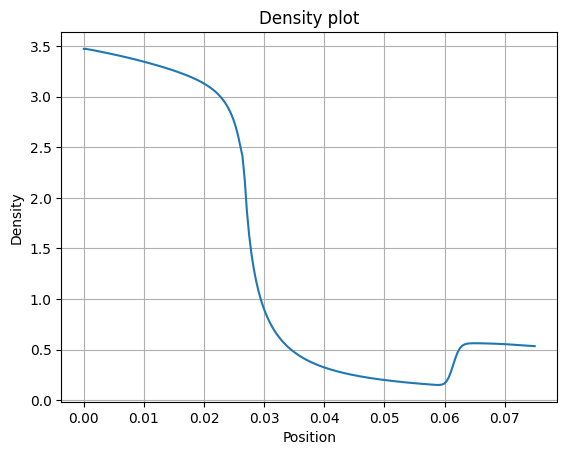

In [7]:
rho = U[0] / A
u = U[1] / U[0]
E = U[2] / A
p = (E - 0.5 * rho * u**2) * (gamma - 1)
plt.plot(x, rho)
plt.title('Density plot')
plt.xlabel('Position')
plt.ylabel('Density')
plt.grid()

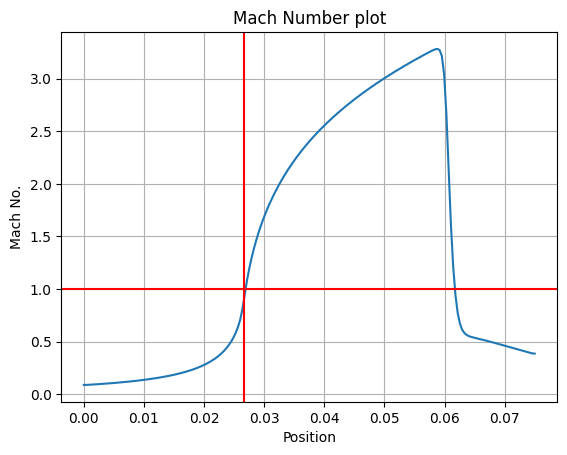

In [8]:
a = np.sqrt(gamma * p / rho)
M = u / a
plt.plot(x, M)
plt.axhline(y = 1.0, c = 'r')
plt.axvline(x = 0.02659, c = 'r')
plt.title('Mach Number plot')
plt.xlabel('Position')
plt.ylabel('Mach No.')
plt.grid()

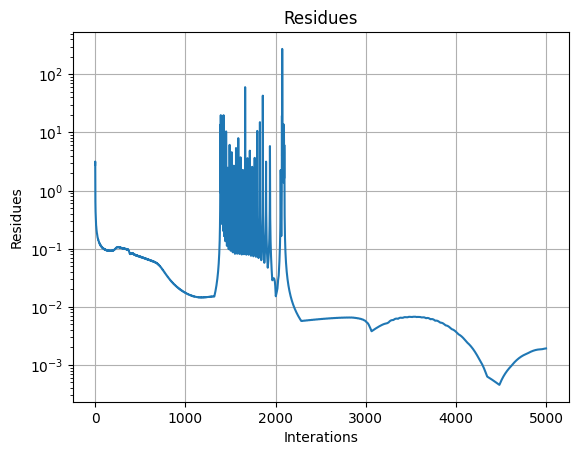

In [9]:
plt.semilogy(residuals)
plt.title('Residues')
plt.xlabel('Interations')
plt.ylabel('Residues')
plt.grid()

# 3 Harten-Lax-van Leer-Contact (HLLC) Scheme


Solves the conservative quasi-one-dimensional Euler equations for a compressible, inviscid ideal gas through a convergent-divergent nozzle.

NUMERICAL METHODS:
1. Spatial Discretization: Finite Volume Method (FVM)
    - Scheme: HLLC (Harten-Lax-van Leer-Contact) Approximate Riemann Solver (1st-Order)
    - Mechanism: Estimates the fastest left and right signal velocities (S_L, S_R)  and the middle contact wave velocity (S_star). Computes the interface fluxes by evaluating the state variables across this three-wave, four-state structure.
    - Advantages: Strictly positivity-preserving for density and pressure. Naturally satisfies the entropy condition (no entropy fix required). Accurately resolves contact discontinuities unlike the standard HLL method.

2. Time Integration: Explicit Forward Euler
    - Scheme: 1st-Order explicit time-marching.
    - Stability: Regulated by a dynamic Courant-Friedrichs-Lewy (CFL) condition

3. Boundary Conditions:
    - Subsonic Inlet: Fixes Total Pressure (p0) and Total Temperature (T0).
    - Subsonic Outlet: Fixes Static Back Pressure (p_exit).

## 3.1 Parameters and Initial Conditions

In [10]:
gamma = 1.4
CFL = 0.2
max_iter = 6000
R = 287

p_back = 5e3
p_in = 3e5
T_in = 600

rho_0 = p_in / (R * T_in)
u_0 = 10.0
E_0 = p_in/(gamma-1) + 0.5*rho_0*u_0**2

U = np.zeros((3, N))
U[0] = rho_0 * A
U[1] = rho_0 * u_0 * A
U[2] = E_0 * A

## 3.2 HLLC Flux computation and Time marching

In [11]:
# -----------------------------
# HLLC FLUX (FIXED)
# -----------------------------
def hllc_flux(U_L, U_R, A_L, A_R):

    rho_L = max(U_L[0]/A_L, 1e-8)
    rho_R = max(U_R[0]/A_R, 1e-8)

    u_L = U_L[1] / U_L[0]
    u_R = U_R[1] / U_R[0]

    E_L = U_L[2] / A_L
    E_R = U_R[2] / A_R

    p_L = max((gamma-1)*(E_L - 0.5*rho_L*u_L**2), 1e-8)
    p_R = max((gamma-1)*(E_R - 0.5*rho_R*u_R**2), 1e-8)

    a_L = np.sqrt(gamma*p_L/rho_L)
    a_R = np.sqrt(gamma*p_R/rho_R)

    S_L = min(u_L - a_L, u_R - a_R)
    S_R = max(u_L + a_L, u_R + a_R)

    S_star = (p_R - p_L + rho_L*u_L*(S_L - u_L) - rho_R*u_R*(S_R - u_R)) / \
             (rho_L*(S_L - u_L) - rho_R*(S_R - u_R) + 1e-12)

    # fluxes
    F_L = np.array([
        U_L[1],
        (rho_L*u_L**2 + p_L)*A_L,
        u_L*(E_L + p_L)*A_L
    ])

    F_R = np.array([
        U_R[1],
        (rho_R*u_R**2 + p_R)*A_R,
        u_R*(E_R + p_R)*A_R
    ])

    if S_L >= 0:
        return F_L

    elif S_L <= 0 <= S_star:

        rho_star = rho_L * (S_L - u_L)/(S_L - S_star)

        E_star = rho_star * (
            E_L/rho_L + (S_star - u_L)*(S_star + p_L/(rho_L*(S_L - u_L)))
        )

        U_star = np.array([
            rho_star*A_L,
            rho_star*S_star*A_L,
            E_star*A_L
        ])

        return F_L + S_L*(U_star - U_L)

    elif S_star <= 0 <= S_R:

        rho_star = rho_R * (S_R - u_R)/(S_R - S_star)

        E_star = rho_star * (
            E_R/rho_R + (S_star - u_R)*(S_star + p_R/(rho_R*(S_R - u_R)))
        )

        U_star = np.array([
            rho_star*A_R,
            rho_star*S_star*A_R,
            E_star*A_R
        ])

        return F_R + S_R*(U_star - U_R)

    else:
        return F_R


# -----------------------------
# TIME LOOP
# -----------------------------
residuals = []

for n in range(max_iter):

    U_old = U.copy()

    rho = U[0]/A
    u   = U[1]/U[0]
    E   = U[2]/A
    p   = (gamma-1)*(E - 0.5*rho*u**2)

    rho = np.maximum(rho, 1e-6)
    p   = np.maximum(p, 1e-6)

    a = np.sqrt(gamma*p/rho)

    dt = CFL * dx / (np.max(np.abs(u) + a) + 1e-8)

    # flux
    F_half = np.zeros((3, N-1))

    for i in range(N-1):
        F_half[:, i] = hllc_flux(U[:, i], U[:, i+1], A[i], A[i+1])

    # source
    J = np.zeros_like(U)
    J[1] = p * dAdx

    # update
    for i in range(1, N-1):
        U[:, i] += dt * (
            -(F_half[:, i] - F_half[:, i-1]) / dx + J[:, i]
        )

    # -----------------------------
    # POSITIVITY FIX
    # -----------------------------
    rho = np.maximum(U[0]/A, 1e-6)
    u   = U[1]/U[0]
    E   = U[2]/A
    p   = np.maximum((gamma-1)*(E - 0.5*rho*u**2), 1e-6)

    U[0] = rho*A
    U[1] = rho*u*A
    U[2] = (p/(gamma-1) + 0.5*rho*u**2)*A

    # -----------------------------
    # BETTER INLET BC
    # -----------------------------
    u[0] = u[1]

    T = T_in - (gamma-1)/2 * u[0]**2 / R
    p[0] = p_in * (T/T_in)**(gamma/(gamma-1))
    rho[0] = p[0]/(R*T)

    U[0,0] = rho[0]*A[0]
    U[1,0] = rho[0]*u[0]*A[0]
    U[2,0] = (p[0]/(gamma-1) + 0.5*rho[0]*u[0]**2)*A[0]

    # outlet (CORRECT BC)
    a_int = np.sqrt(gamma * p[-2] / rho[-2])
    M_int = u[-2] / a_int

    if M_int < 1:
        # subsonic → impose pressure
        rho_out = rho[-2]
        u_out   = u[-2]
        p_out   = p_back
    else:
        # supersonic → extrapolate
        rho_out = rho[-2]
        u_out   = u[-2]
        p_out   = p[-2]

    E_out = p_out/(gamma-1) + 0.5*rho_out*u_out**2

    U[0,-1] = rho_out * A[-1]
    U[1,-1] = rho_out * u_out * A[-1]
    U[2,-1] = E_out * A[-1]

    res = np.max(np.abs((U - U_old)/(U_old + 1e-8)))
    residuals.append(res)

    if n % 200 == 0:
        print(f"Iter {n}, Residual {res:.3e}")

Iter 0, Residual 9.832e-01
Iter 200, Residual 1.999e-02
Iter 400, Residual 1.377e-02
Iter 600, Residual 1.199e-02
Iter 800, Residual 5.451e-03
Iter 1000, Residual 3.207e-03
Iter 1200, Residual 2.643e-03
Iter 1400, Residual 3.213e-03
Iter 1600, Residual 6.969e-03
Iter 1800, Residual 1.134e-02
Iter 2000, Residual 1.413e-02
Iter 2200, Residual 1.639e-02
Iter 2400, Residual 1.609e-02
Iter 2600, Residual 1.757e-02
Iter 2800, Residual 1.911e-02
Iter 3000, Residual 1.913e-02
Iter 3200, Residual 2.031e-02
Iter 3400, Residual 2.067e-02
Iter 3600, Residual 2.005e-02
Iter 3800, Residual 2.112e-02
Iter 4000, Residual 3.941e-04
Iter 4200, Residual 4.631e-04
Iter 4400, Residual 3.857e-04
Iter 4600, Residual 2.567e-04
Iter 4800, Residual 1.290e-04
Iter 5000, Residual 8.375e-05
Iter 5200, Residual 8.621e-05
Iter 5400, Residual 1.650e-04
Iter 5600, Residual 2.126e-04
Iter 5800, Residual 2.030e-04


## 3.3 Post Processing and Visualisation

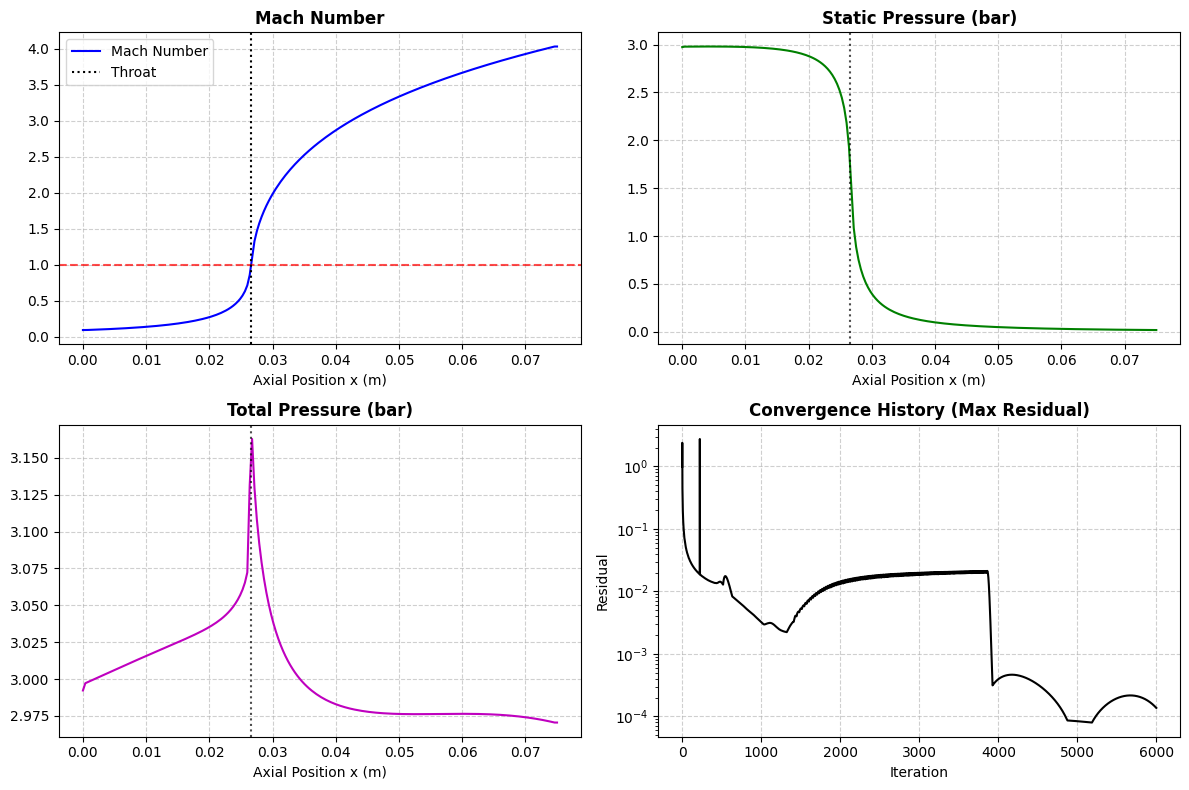

In [12]:
rho = U[0]/A
u   = U[1]/U[0]
E   = U[2]/A
p   = (gamma-1)*(E - 0.5*rho*u**2)
a   = np.sqrt(gamma*p/rho)
M   = u/a

# Calculate Total Pressure for plotting
p_total = p * (1 + (gamma-1)/2 * M**2)**(gamma/(gamma-1))

# Define throat position for plotting (matches your geometry)
x_t = 0.02659

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Top Left: Mach Number
axs[0,0].plot(x, M, 'b-', linewidth=1.5, label='Mach Number')
axs[0,0].axhline(1, color='r', linestyle='--', alpha=0.7)
axs[0,0].axvline(x_t, color='k', linestyle=':', label='Throat')
axs[0,0].set_title("Mach Number", fontweight='bold')
axs[0,0].set_xlabel("Axial Position x (m)")
axs[0,0].grid(True, linestyle='--', alpha=0.6)
axs[0,0].legend()

# Top Right: Static Pressure
axs[0,1].plot(x, p/1e5, 'g-', linewidth=1.5)
axs[0,1].axvline(x_t, color='k', linestyle=':', alpha=0.7)
axs[0,1].set_title("Static Pressure (bar)", fontweight='bold')
axs[0,1].set_xlabel("Axial Position x (m)")
axs[0,1].grid(True, linestyle='--', alpha=0.6)

# Bottom Left: Total Pressure
axs[1,0].plot(x, p_total/1e5, 'm-', linewidth=1.5)
axs[1,0].axvline(x_t, color='k', linestyle=':', alpha=0.7)
axs[1,0].set_title("Total Pressure (bar)", fontweight='bold')
axs[1,0].set_xlabel("Axial Position x (m)")
axs[1,0].grid(True, linestyle='--', alpha=0.6)

# Bottom Right: Residuals
axs[1,1].semilogy(residuals, 'k-', linewidth=1.5)
axs[1,1].set_title("Convergence History (Max Residual)", fontweight='bold')
axs[1,1].set_xlabel("Iteration")
axs[1,1].set_ylabel("Residual")
axs[1,1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 3.4 Exact Analytical solver

In [13]:
from scipy.optimize import brentq

def isentropic_area_mach(M, A_ratio, gamma=1.4):
    """The implicit Area-Mach equation to solve for M."""
    if M <= 0: return 1e6 # Prevent negative Mach numbers in solver
    term1 = 2 / (gamma + 1)
    term2 = 1 + 0.5 * (gamma - 1) * M**2
    power = (gamma + 1) / (2 * (gamma - 1))
    return (1.0 / M) * (term1 * term2)**power - A_ratio

def get_analytical_solution(x, A, p_in, p_back, x_t, gamma=1.4):
    A_star = get_nozzle_area(x_t)
    A_ratio = A / A_star

    M_sub = np.zeros_like(x)
    M_sup = np.zeros_like(x)

    for i, AR in enumerate(A_ratio):
        if np.isclose(AR, 1.0):
            M_sub[i] = 1.0
        else:
            try:
                M_sub[i] = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR, gamma))
            except ValueError:
                M_sub[i] = 0.0

        if x[i] >= x_t and AR > 1.0001:
            try:
                M_sup[i] = brentq(isentropic_area_mach, 1.0001, 20.0, args=(AR, gamma))
            except ValueError:
                M_sup[i] = 1.0
        else:
            M_sup[i] = M_sub[i]

    # Quick check for perfectly expanded / vacuum case
    # If p_back is very low, the flow is perfectly supersonic with no shock.
    p_exit_supersonic = p_in / (1 + 0.5*(gamma-1)*M_sup[-1]**2)**(gamma/(gamma-1))

    if p_back <= p_exit_supersonic + 100:  # Vacuum/fully supersonic case
        return M_sup, p_in / (1 + 0.5*(gamma-1)*M_sup**2)**(gamma/(gamma-1)), np.full_like(x, p_in), x[-1]

    # --- Shock location logic ---
    p_exit_calc = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= x_t:
            p_exit_calc[i] = 1e9
            continue

        M1 = M_sup[i]
        p02_p01 = (((gamma+1)*M1**2) / ((gamma-1)*M1**2 + 2))**(gamma/(gamma-1)) * \
                  ((gamma+1) / (2*gamma*M1**2 - (gamma-1)))**(1/(gamma-1))

        A_star_new = A_star / p02_p01
        AR_exit = A[-1] / A_star_new

        if np.isclose(AR_exit, 1.0):
            M_exit = 1.0
        else:
            try:
                M_exit = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR_exit, gamma))
            except ValueError:
                M_exit = 0.5

        p0_exit = p_in * p02_p01
        p_exit_calc[i] = p0_exit / (1 + 0.5*(gamma-1)*M_exit**2)**(gamma/(gamma-1))

    shock_idx = np.argmin(np.abs(p_exit_calc - p_back))

    M_exact = np.zeros_like(x)
    p_exact = np.zeros_like(x)
    p0_exact = np.zeros_like(x)
    M1_shock = M_sup[shock_idx]

    for i in range(len(x)):
        if x[i] < x[shock_idx]:
            M_exact[i] = M_sup[i]
            p0_exact[i] = p_in
        else:
            # FIXED BUG HERE: Changed M1 to M1_shock in the denominator
            p02_p01 = (((gamma+1)*M1_shock**2) / ((gamma-1)*M1_shock**2 + 2))**(gamma/(gamma-1)) * \
                      ((gamma+1) / (2*gamma*M1_shock**2 - (gamma-1)))**(1/(gamma-1))
            A_star_new = A_star / p02_p01

            AR_local = max(A[i]/A_star_new, 1.00001)
            try:
                M_exact[i] = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR_local, gamma))
            except ValueError:
                M_exact[i] = 0.5

            p0_exact[i] = p_in * p02_p01

        p_exact[i] = p0_exact[i] / (1 + 0.5*(gamma-1)*M_exact[i]**2)**(gamma/(gamma-1))

    return M_exact, p_exact, p0_exact, x[shock_idx]

# --- RUNNING THE ANALYTICAL SOLVER ---
x_t = 0.02659# Ensure throat location is defined
M_exact, p_exact, p0_exact, x_shock = get_analytical_solution(x, A, p_in, p_back, x_t, gamma)
# ==============================================================================
# ERROR QUANTIFICATION (% Error)
# ==============================================================================
# 1. L2 Error Norm
error_L2 = np.sqrt(np.mean((M - M_exact)**2))

# 2. Percentage Error (Avoid dividing by zero at inlet)
M_exact_safe = np.where(M_exact == 0, 1e-8, M_exact)
percent_error_array = np.abs((M - M_exact_safe) / M_exact_safe) * 100
mape = np.mean(percent_error_array)
max_pe = np.max(percent_error_array)

print("\n--- 1st-Order Solver Validation Metrics ---")
print(f"L2 Norm Error (Mach): {error_L2:.4e}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Maximum Percentage Error: {max_pe:.2f}%")
print("-------------------------------------------\n")


--- 1st-Order Solver Validation Metrics ---
L2 Norm Error (Mach): 2.6809e-01
Mean Absolute Percentage Error (MAPE): 7.69%
Maximum Percentage Error: 835.32%
-------------------------------------------



## 3.5 Validation with first order HLLC

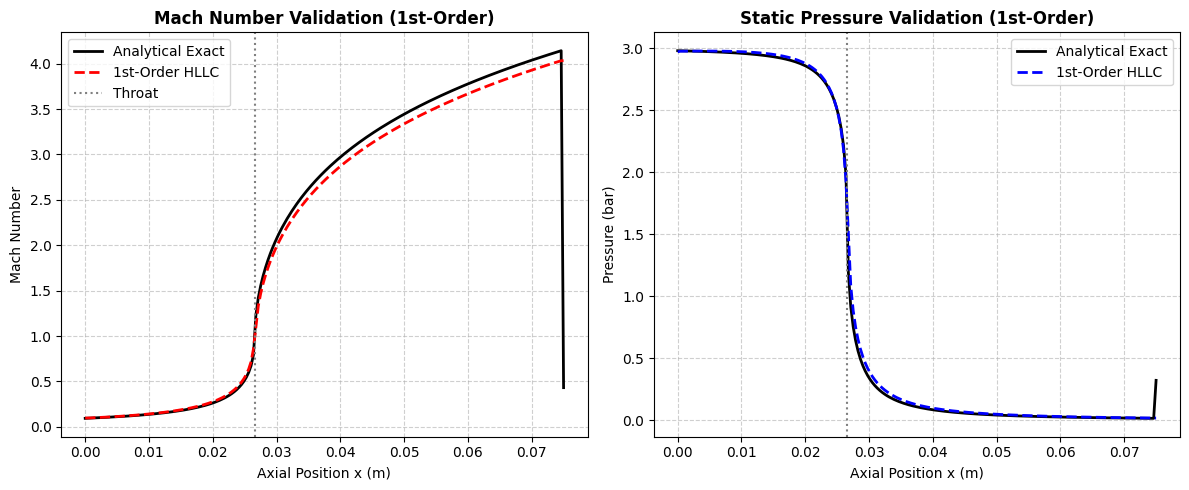

In [14]:
# ==============================================================================
# VALIDATION PLOTTING (Mach & Pressure)
# ==============================================================================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Mach Number Comparison
axs[0].plot(x, M_exact, 'k-', linewidth=2, label='Analytical Exact')
axs[0].plot(x, M, 'r--', linewidth=2, label='1st-Order HLLC')
axs[0].axvline(x_t, color='gray', linestyle=':', label='Throat')
axs[0].set_title("Mach Number Validation (1st-Order)", fontweight='bold')
axs[0].set_xlabel("Axial Position x (m)")
axs[0].set_ylabel("Mach Number")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# Static Pressure Comparison
axs[1].plot(x, p_exact/1e5, 'k-', linewidth=2, label='Analytical Exact')
axs[1].plot(x, p/1e5, 'b--', linewidth=2, label='1st-Order HLLC')
axs[1].axvline(x_t, color='gray', linestyle=':')
axs[1].set_title("Static Pressure Validation (1st-Order)", fontweight='bold')
axs[1].set_xlabel("Axial Position x (m)")
axs[1].set_ylabel("Pressure (bar)")
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4 HLLC - MUSCL Scheme with Van Leer Limiter


HIGH-RESOLUTION QUASI-1D EULER SOLVER

A state-of-the-art, high-resolution finite volume solver for the quasi-1D Euler equations, specifically designed to capture sharp shock waves without numerical ringing.

NUMERICAL METHODS:
1. Spatial Discretization: 2nd-Order MUSCL Reconstruction
    - Scheme: Monotone Upstream-centered Schemes for Conservation Laws.
    - Mechanism: Extrapolates primitive variables (density, velocity, pressure) to cell interfaces using local gradients to achieve 2nd-order spatial accuracy in smooth flow.

2. TVD Flux Limiter: Van Leer Limiter
    - Purpose: Enforces the Total Variation Diminishing (TVD) property. Detects discontinuities (shocks) and locally reverts the spatial reconstruction to 1st-order to strictly prevent spurious numerical oscillations (Gibbs phenomenon).

3. Interface Fluxes: HLLC Approximate Riemann Solver
    - Purpose: Resolves the interface states using a robust, positivity-preserving three-wave solver.

4. Time Integration: 2nd-Order SSP-RK2
    - Scheme: Strong Stability Preserving Runge-Kutta (Predictor-Corrector).
    - Purpose: Ensures temporal stability when coupled with higher-order TVD spatial schemes.

5. Boundary Conditions:
    - Subsonic Outlet utilizes Characteristic Non-Reflecting conditions (Riemann Invariants) to prevent acoustic waves from bouncing back into the computational domain.

## 4.1 Parameters and Initial Conditions


In [15]:
gamma = 1.4
CFL = 0.4
max_iter = 6000
R = 287
p_back = 5e4

p_in = 3e5
T_in = 600

rho_0 = p_in / (R * T_in)
u_0 = 10.0
E_0 = p_in/(gamma-1) + 0.5*rho_0*u_0**2

U = np.zeros((3, N))
U[0] = rho_0 * A
U[1] = rho_0 * u_0 * A
U[2] = E_0 * A


## 4.2 TVD Limiter and HLLC Flux

In [16]:
def van_leer_limiter(r):
    """Van Leer flux limiter to prevent oscillations near shocks."""
    return (r + np.abs(r)) / (1.0 + np.abs(r) + 1e-12)

def hllc_flux(U_L, U_R, A_face):
    """Standard HLLC Riemann Solver for Face Fluxes"""
    rho_L = max(U_L[0]/A_face, 1e-8)
    rho_R = max(U_R[0]/A_face, 1e-8)

    u_L = U_L[1] / max(U_L[0], 1e-8)
    u_R = U_R[1] / max(U_R[0], 1e-8)

    E_L = U_L[2] / A_face
    E_R = U_R[2] / A_face

    p_L = max((gamma-1)*(E_L - 0.5*rho_L*u_L**2), 1e-8)
    p_R = max((gamma-1)*(E_R - 0.5*rho_R*u_R**2), 1e-8)

    a_L = np.sqrt(gamma*p_L/rho_L)
    a_R = np.sqrt(gamma*p_R/rho_R)

    # Wave speed estimates
    S_L = min(u_L - a_L, u_R - a_R)
    S_R = max(u_L + a_L, u_R + a_R)

    # Contact wave speed
    S_star = (p_R - p_L + rho_L*u_L*(S_L - u_L) - rho_R*u_R*(S_R - u_R)) / \
             (rho_L*(S_L - u_L) - rho_R*(S_R - u_R) + 1e-12)

    F_L = np.array([U_L[1], (rho_L*u_L**2 + p_L)*A_face, u_L*(E_L + p_L)*A_face])
    F_R = np.array([U_R[1], (rho_R*u_R**2 + p_R)*A_face, u_R*(E_R + p_R)*A_face])

    if S_L >= 0:
        return F_L
    elif S_L <= 0 <= S_star:
        rho_star = rho_L * (S_L - u_L)/(S_L - S_star)
        E_star = rho_star * (E_L/rho_L + (S_star - u_L)*(S_star + p_L/(rho_L*(S_L - u_L))))
        U_star = np.array([rho_star*A_face, rho_star*S_star*A_face, E_star*A_face])
        return F_L + S_L*(U_star - U_L)
    elif S_star <= 0 <= S_R:
        rho_star = rho_R * (S_R - u_R)/(S_R - S_star)
        E_star = rho_star * (E_R/rho_R + (S_star - u_R)*(S_star + p_R/(rho_R*(S_R - u_R))))
        U_star = np.array([rho_star*A_face, rho_star*S_star*A_face, E_star*A_face])
        return F_R + S_R*(U_star - U_R)
    else:
        return F_R

def compute_rhs(U_state):
    """Computes the Right Hand Side (spatial derivatives) using MUSCL reconstruction."""
    rho = np.maximum(U_state[0]/A, 1e-6)
    u   = U_state[1]/U_state[0]
    E   = U_state[2]/A
    p   = np.maximum((gamma-1)*(E - 0.5*rho*u**2), 1e-6)

    # Store primitive variables for MUSCL reconstruction
    V = np.array([rho, u, p])

    # Initialize Left and Right face states
    V_L = np.zeros((3, N-1))
    V_R = np.zeros((3, N-1))

    # 1st order boundaries, 2nd order MUSCL interior
    for j in range(3): # For rho, u, p
        # 1st order at the absolute boundaries
        V_L[j, 0] = V[j, 0]
        V_R[j, 0] = V[j, 1]

        V_L[j, N-2] = V[j, N-2]
        V_R[j, N-2] = V[j, N-1]

        for i in range(1, N-2):
            # Left state at face i+1/2 (extrapolating forward from cell i)
            dq_L_minus = V[j, i] - V[j, i-1]
            dq_L_plus  = V[j, i+1] - V[j, i]

            r_L = dq_L_minus / (dq_L_plus + 1e-12) if dq_L_plus != 0 else 0.0
            phi_L = van_leer_limiter(r_L)
            V_L[j, i] = V[j, i] + 0.5 * phi_L * dq_L_plus

            # Right state at face i+1/2 (extrapolating backward from cell i+1)
            dq_R_minus = V[j, i+1] - V[j, i]
            dq_R_plus  = V[j, i+2] - V[j, i+1]

            r_R = dq_R_plus / (dq_R_minus + 1e-12) if dq_R_minus != 0 else 0.0 # Flipped ratio!
            phi_R = van_leer_limiter(r_R)
            V_R[j, i] = V[j, i+1] - 0.5 * phi_R * dq_R_minus # Using local local backward gradient!

    # Convert reconstructed primitive variables back to conservative
    U_L_face = np.zeros((3, N-1))
    U_R_face = np.zeros((3, N-1))

    for i in range(N-1):
        U_L_face[0, i] = V_L[0, i] * A_face[i]
        U_L_face[1, i] = V_L[0, i] * V_L[1, i] * A_face[i]
        U_L_face[2, i] = (V_L[2, i]/(gamma-1) + 0.5*V_L[0, i]*V_L[1, i]**2) * A_face[i]

        U_R_face[0, i] = V_R[0, i] * A_face[i]
        U_R_face[1, i] = V_R[0, i] * V_R[1, i] * A_face[i]
        U_R_face[2, i] = (V_R[2, i]/(gamma-1) + 0.5*V_R[0, i]*V_R[1, i]**2) * A_face[i]

    # Calculate Interface Fluxes
    F_face = np.zeros((3, N-1))
    for i in range(N-1):
        F_face[:, i] = hllc_flux(U_L_face[:, i], U_R_face[:, i], A_face[i])

    # Calculate Source Term (Pressure acting on area change)
    J = np.zeros_like(U_state)
    J[1] = p * dAdx

    # Assemble Right Hand Side: dU/dt = RHS
    RHS = np.zeros_like(U_state)
    for i in range(1, N-1):
        RHS[:, i] = -(F_face[:, i] - F_face[:, i-1]) / dx + J[:, i]

    return RHS # Removed u and a_L as they are not used and a_L causes NameError


## 4.3 Time marching using SSP-RK2

In [17]:
residuals = []

for n in range(max_iter):
    U_old = U.copy()

    # Calculate timestep
    rho_tmp = np.maximum(U[0]/A, 1e-6)
    u_tmp = U[1]/U[0]
    p_tmp = np.maximum((gamma-1)*(U[2]/A - 0.5*rho_tmp*u_tmp**2), 1e-6)
    a_tmp = np.sqrt(gamma*p_tmp/rho_tmp)
    dt = CFL * dx / (np.max(np.abs(u_tmp) + a_tmp) + 1e-8)

    # RK2 Step 1
    RHS_1 = compute_rhs(U)
    U_1 = U + dt * RHS_1

    # Boundary Conditions for Step 1
    u_in_1 = U_1[1,1]/U_1[0,1]
    T_1 = T_in - (gamma-1)/2 * u_in_1**2 / R
    p_in_1 = p_in * (T_1/T_in)**(gamma/(gamma-1))
    rho_in_1 = p_in_1/(R*T_1)
    U_1[0,0] = rho_in_1*A[0]
    U_1[1,0] = rho_in_1*u_in_1*A[0]
    U_1[2,0] = (p_in_1/(gamma-1) + 0.5*rho_in_1*u_in_1**2)*A[0]

    # --- NON-REFLECTIVE SUBSONIC OUTLET (CHARACTERISTIC BC) ---
    # --- SMART OUTLET BC (Step 1) ---
    rho_int = U_1[0,-2] / A[-2]
    u_int   = U_1[1,-2] / U_1[0,-2]
    p_int   = (gamma-1)*(U_1[2,-2]/A[-2] - 0.5*rho_int*u_int**2)
    a_int   = np.sqrt(gamma * p_int / rho_int)

    if u_int >= a_int:
        # SUPERSONIC EXIT: Flow is blind to ambient pressure
        U_1[0,-1] = rho_int * A[-1]
        U_1[1,-1] = rho_int * u_int * A[-1]
        U_1[2,-1] = (p_int/(gamma-1) + 0.5*rho_int*u_int**2)*A[-1]
    else:
        # SUBSONIC EXIT: Characteristic Non-Reflecting BC
        entropy_int = p_int / (rho_int**gamma)
        rho_out = (p_back / entropy_int)**(1/gamma)
        R_plus = u_int + (2 * a_int) / (gamma - 1)
        a_out = np.sqrt(gamma * p_back / rho_out)
        u_out = R_plus - (2 * a_out) / (gamma - 1)

        U_1[0,-1] = rho_out * A[-1]
        U_1[1,-1] = rho_out * u_out * A[-1]
        U_1[2,-1] = (p_back/(gamma-1) + 0.5*rho_out*u_out**2)*A[-1]

    # RK2 Step 2
    RHS_2 = compute_rhs(U_1)
    U = 0.5 * U + 0.5 * U_1 + 0.5 * dt * RHS_2

    # Final Boundary Conditions
    u_in = U[1,1]/U[0,1]
    T = T_in - (gamma-1)/2 * u_in**2 / R
    p_in_new = p_in * (T/T_in)**(gamma/(gamma-1))
    rho_in_new = p_in_new/(R*T)
    U[0,0] = rho_in_new*A[0]
    U[1,0] = rho_in_new*u_in*A[0]
    U[2,0] = (p_in_new/(gamma-1) + 0.5*rho_in_new*u_in**2)*A[0]

    rho_out = U[0,-2]/A[-2]
    u_out   = U[1,-2]/U[0,-2]
    U[0,-1] = rho_out * A[-1]
    U[1,-1] = rho_out * u_out * A[-1]
    U[2,-1] = (p_back/(gamma-1) + 0.5*rho_out*u_out**2)*A[-1]

    # Calculate L2 Density Residual
    res = np.sqrt(np.mean(((U[0] - U_old[0]) / dt)**2))
    residuals.append(res)

    if n % 200 == 0:
        print(f"Iter {n:4d} | Residual: {res:.3e}")

Iter    0 | Residual: 5.563e+05
Iter  200 | Residual: 9.322e+04
Iter  400 | Residual: 5.577e+04
Iter  600 | Residual: 3.950e+04
Iter  800 | Residual: 2.976e+04
Iter 1000 | Residual: 3.252e+04
Iter 1200 | Residual: 4.618e+04
Iter 1400 | Residual: 5.113e+04
Iter 1600 | Residual: 6.039e+04
Iter 1800 | Residual: 6.290e+04
Iter 2000 | Residual: 1.947e+04
Iter 2200 | Residual: 3.451e+04
Iter 2400 | Residual: 4.492e+04
Iter 2600 | Residual: 2.414e+04
Iter 2800 | Residual: 2.586e+04
Iter 3000 | Residual: 1.468e+04
Iter 3200 | Residual: 3.871e+03
Iter 3400 | Residual: 5.089e+03
Iter 3600 | Residual: 6.220e+03
Iter 3800 | Residual: 5.740e+03
Iter 4000 | Residual: 6.752e+03
Iter 4200 | Residual: 6.342e+03
Iter 4400 | Residual: 5.424e+03
Iter 4600 | Residual: 3.312e+03
Iter 4800 | Residual: 1.156e+03
Iter 5000 | Residual: 5.712e+02
Iter 5200 | Residual: 7.174e+02
Iter 5400 | Residual: 8.712e+02
Iter 5600 | Residual: 7.358e+02
Iter 5800 | Residual: 4.096e+03


## 4.4 Post Processing and Visualisation


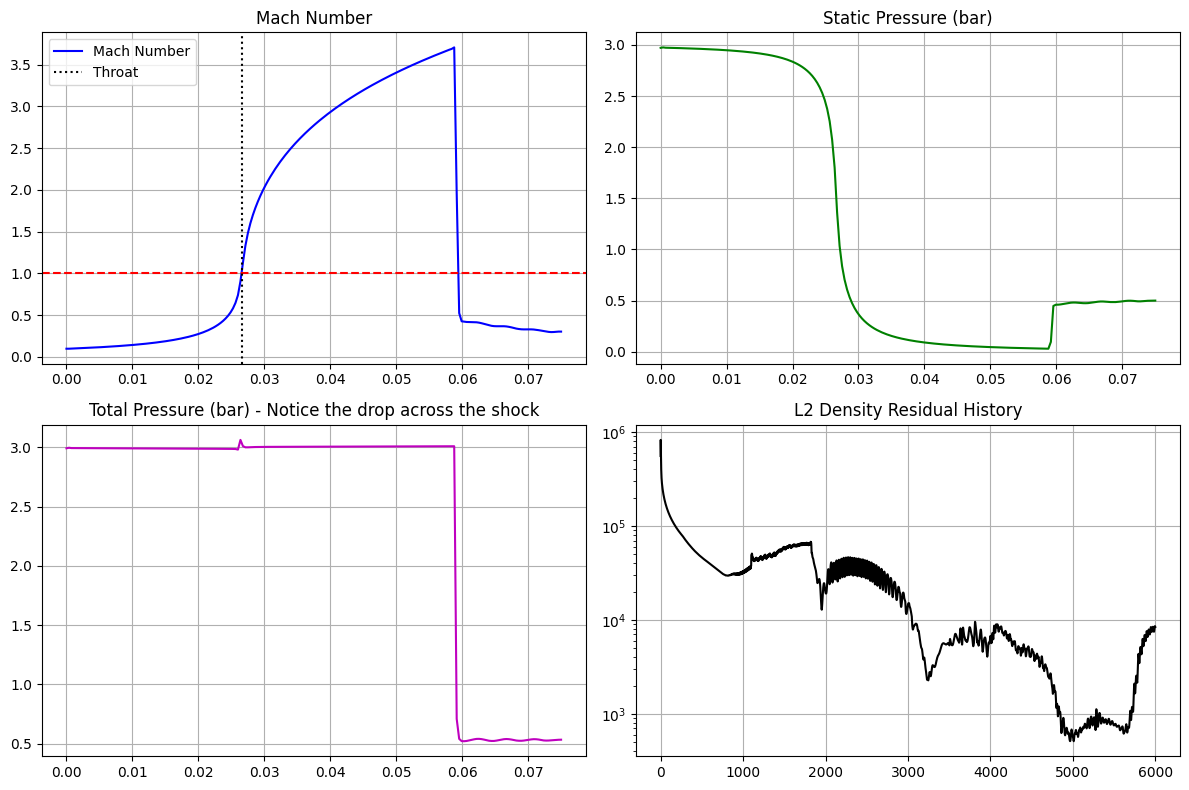

In [18]:
rho = U[0]/A
u   = U[1]/U[0]
E   = U[2]/A
p   = (gamma-1)*(E - 0.5*rho*u**2)
a   = np.sqrt(gamma*p/rho)
M   = u/a
p_total = p * (1 + 0.5*(gamma-1)*M**2)**(gamma/(gamma-1))

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].plot(x, M, 'b-', label='Mach Number')
axs[0,0].axhline(1, color='r', linestyle='--')
axs[0,0].axvline(x_t, color='k', linestyle=':', label='Throat') # Use x_t for throat location
axs[0,0].set_title("Mach Number")
axs[0,0].grid()
axs[0,0].legend()

axs[0,1].plot(x, p/1e5, 'g-')
axs[0,1].set_title("Static Pressure (bar)")
axs[0,1].grid()

axs[1,0].plot(x, p_total/1e5, 'm-')
axs[1,0].set_title("Total Pressure (bar) - Notice the drop across the shock")
axs[1,0].grid()

axs[1,1].semilogy(residuals, 'k-')
axs[1,1].set_title("L2 Density Residual History")
axs[1,1].grid()

plt.tight_layout()
plt.show()

## 4.5 Exact Analytical Solver

Computes the exact, analytical mathematical solution for quasi-1D nozzle flow with a stationary normal shock. Used to validate the numerical FVM solver and quantify discretization errors.

METHODOLOGY:
1. Isentropic Flow: Utilizes the Brent's method root-finding algorithm (brentq) to solve the implicit Area-Mach relation for both subsonic and supersonic branches.
2. Shock Fitting: Iteratively applies Rankine-Hugoniot normal shock relations across the diverging section to locate the exact coordinate where the entropy rise (total pressure drop) perfectly satisfies the imposed static back pressure (p_back).
3. Validation: Overlays the numerical FVM results against the analytical ground truth and computes the L-2 Error Norm for the Mach number profile.

In [19]:
def isentropic_area_mach(M, A_ratio, gamma=1.4):
    """The implicit Area-Mach equation to solve for M."""
    if M <= 0: return 1e6 # Prevent negative Mach numbers in solver
    term1 = 2 / (gamma + 1)
    term2 = 1 + 0.5 * (gamma - 1) * M**2
    power = (gamma + 1) / (2 * (gamma - 1))
    return (1.0 / M) * (term1 * term2)**power - A_ratio

def isentropic_area_mach(M, A_ratio, gamma=1.4):
    """The implicit Area-Mach equation to solve for M."""
    term1 = 2 / (gamma + 1)
    term2 = 1 + 0.5 * (gamma - 1) * M**2
    power = (gamma + 1) / (2 * (gamma - 1))
    return (1.0 / M) * (term1 * term2)**power - A_ratio

def get_analytical_solution(x, A, p_in, p_back, x_t, gamma=1.4):
    # Dynamically find the exact theoretical throat area!
    # Correctly use x_t to get the throat area
    A_star = get_nozzle_area(x_t)
    A_ratio = A / A_star

    M_sub = np.zeros_like(x)
    M_sup = np.zeros_like(x)

    for i, AR in enumerate(A_ratio):
        if np.isclose(AR, 1.0): # Handle the throat where M_sub should be 1.0
            M_sub[i] = 1.0
        else:
            # Use brentq with strict brackets instead of fsolve
            # Ensure the brackets are valid for the given A_ratio. If A_ratio is too high,
            # f(a) and f(b) might have the same sign. The minimum A_ratio is 1.0.
            # For practical purposes in a nozzle, this might happen at the inlet if area is very large.
            # Let's try a slightly wider range for robustness if necessary, or just assign 0 if it's the inlet and AR is huge.
            # For now, let's just propagate the error. The fix below addresses the root cause of bad A_star.
            try:
                M_sub[i] = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR, gamma))
            except ValueError:
                print(f"Warning: brentq failed for M_sub at x={x[i]:.4f}, AR={AR:.4f}")
                M_sub[i] = 0.0 # Assign a sensible default or handle specifically

        if x[i] >= x_t and AR > 1.0001: # Use x_t for throat location
            try:
                M_sup[i] = brentq(isentropic_area_mach, 1.0001, 5.0, args=(AR, gamma))
            except ValueError:
                print(f"Warning: brentq failed for M_sup at x={x[i]:.4f}, AR={AR:.4f}")
                M_sup[i] = 1.0 # Assign a sensible default
        else:
            M_sup[i] = M_sub[i]

    p_exit_calc = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= x_t: # Use x_t for throat location
            p_exit_calc[i] = 1e9
            continue

        M1 = M_sup[i]

        # Normal Shock Relations
        p02_p01 = (((gamma+1)*M1**2) / ((gamma-1)*M1**2 + 2))**(gamma/(gamma-1)) * \
                  ((gamma+1) / (2*gamma*M1**2 - (gamma-1)))**(1/(gamma-1))

        A_star_new = A_star / p02_p01
        AR_exit = A[-1] / A_star_new

        if np.isclose(AR_exit, 1.0): # Handle case where M_exit should be 1.0
            M_exit = 1.0
        else:
            try:
                M_exit = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR_exit, gamma))
            except ValueError:
                print(f"Warning: brentq failed for M_exit at outlet, AR_exit={AR_exit:.4f}")
                M_exit = 0.5 # Assign a sensible default

        p0_exit = p_in * p02_p01
        p_exit_calc[i] = p0_exit / (1 + 0.5*(gamma-1)*M_exit**2)**(gamma/(gamma-1))

    shock_idx = np.argmin(np.abs(p_exit_calc - p_back))

    M_exact = np.zeros_like(x)
    p_exact = np.zeros_like(x)
    p0_exact = np.zeros_like(x)
    M1_shock = M_sup[shock_idx]

    for i in range(len(x)):
        if x[i] < x[shock_idx]:
            M_exact[i] = M_sup[i]
            p0_exact[i] = p_in
        else:

            p02_p01 = (((gamma+1)*M1_shock**2) / ((gamma-1)*M1_shock**2 + 2))**(gamma/(gamma-1)) * \
                      ((gamma+1) / (2*gamma*M1_shock**2 - (gamma-1)))**(1/(gamma-1))
            A_star_new = A_star / p02_p01

            # Use brentq for the post-shock subsonic flow
            AR_local = max(A[i]/A_star_new, 1.00001) # Prevents bracket failure at exact 1.0
            try:
                M_exact[i] = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR_local, gamma))
            except ValueError:
                print(f"Warning: brentq failed for M_exact post-shock at x={x[i]:.4f}, AR_local={AR_local:.4f}")
                M_exact[i] = 0.5 # Assign a sensible default

            p0_exact[i] = p_in * p02_p01

        p_exact[i] = p0_exact[i] / (1 + 0.5*(gamma-1)*M_exact[i]**2)**(gamma/(gamma-1))

    return M_exact, p_exact, p0_exact, x[shock_idx]

# --- RUNNING THE ANALYTICAL SOLVER ---
# The numerical solution uses N=301 for x and A, so the analytical solution must match
N_analytical = 200 # Must match N from MUSCL solver in cell 8Dzt60ZjBhBM
x_analytical = np.linspace(0, 0.075, N_analytical)
A_analytical = get_nozzle_area(x_analytical)

x_t = 0.02659 # Corrected throat position to match nozzle geometry
M_exact, p_exact, p0_exact, x_shock = get_analytical_solution(x_analytical, A_analytical, p_in, p_back, x_t, gamma)

print(f"Analytical Shock Location: x = {x_shock:.3f} m")

# ==============================================================================
# ERROR QUANTIFICATION (% Error)
# 1. L2 Error Norm
error_L2 = np.sqrt(np.mean((M - M_exact)**2))

# 2. Percentage Error (Avoid dividing by zero at inlet)
M_exact_safe = np.where(M_exact == 0, 1e-8, M_exact)
percent_error_array = np.abs((M - M_exact_safe) / M_exact_safe) * 100
mape = np.mean(percent_error_array)
max_pe = np.max(percent_error_array)

print("\n--- 2nd-Order (MUSCL) Solver Validation Metrics ---")
print(f"L2 Norm Error (Mach): {error_L2:.4e}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Maximum Percentage Error: {max_pe:.2f}%")
print("---------------------------------------------------\n")

# --- QUANTIFYING THE ERROR ---
# Calculate the L2 Error Norm for the Mach number
error_L2 = np.sqrt(np.mean((M - M_exact)**2))
print(f"L2 Norm Error for Mach Number: {error_L2:.4e}")

Analytical Shock Location: x = 0.058 m

--- 2nd-Order (MUSCL) Solver Validation Metrics ---
L2 Norm Error (Mach): 4.1436e-01
Mean Absolute Percentage Error (MAPE): 16.31%
Maximum Percentage Error: 759.07%
---------------------------------------------------

L2 Norm Error for Mach Number: 4.1436e-01


## 4.6 Validation with MUSCL-HLLC

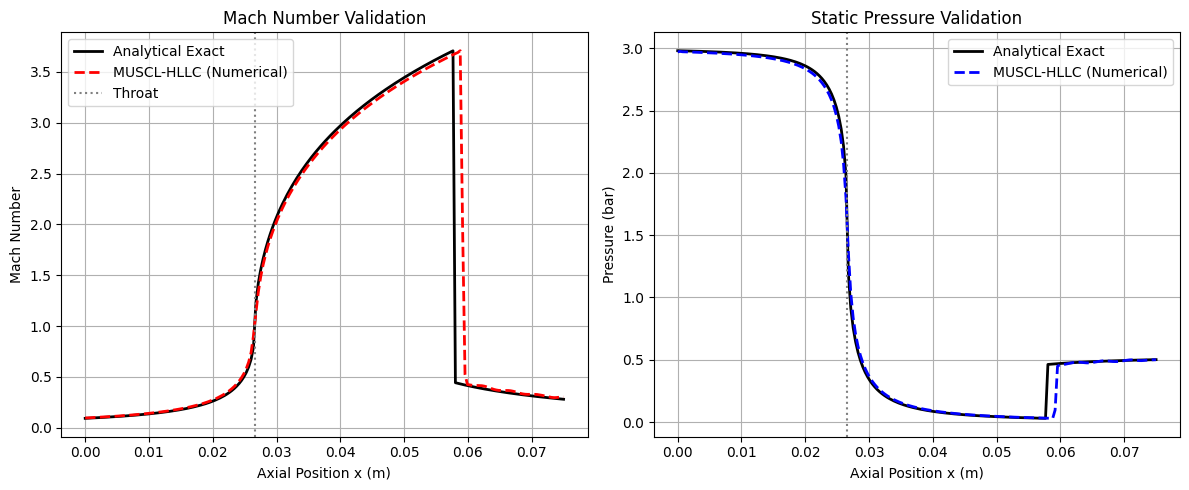

In [20]:
plt.figure(figsize=(12, 5))

# Mach Number Comparison
plt.subplot(1, 2, 1)
plt.plot(x_analytical, M_exact, 'k-', linewidth=2, label='Analytical Exact')
plt.plot(x_analytical, M, 'r--', linewidth=2, label='MUSCL-HLLC (Numerical)')
plt.axvline(x_t, color='gray', linestyle=':', label='Throat') # Use x_t for throat location
plt.title("Mach Number Validation")
plt.xlabel("Axial Position x (m)")
plt.ylabel("Mach Number")
plt.legend()
plt.grid(True)

# Pressure Comparison
plt.subplot(1, 2, 2)
plt.plot(x_analytical, p_exact/1e5, 'k-', linewidth=2, label='Analytical Exact')
plt.plot(x_analytical, p/1e5, 'b--', linewidth=2, label='MUSCL-HLLC (Numerical)')
plt.axvline(x_t, color='gray', linestyle=':') # Use x_t for throat location
plt.title("Static Pressure Validation")
plt.xlabel("Axial Position x (m)")
plt.ylabel("Pressure (bar)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5 HLLC - MUSCL Scheme with MinMod Limiter



## 5.1 Parameters and Initial Conditions

In [29]:
gamma = 1.4
CFL = 0.34 # Lowered for strict TVD stability with 2nd-order MUSCL
max_iter = 6000
R = 296.8
p_back = 5e3

p_in = 3e5
T_in = 600

rho_0 = p_in / (R * T_in)
u_0 = 10.0
E_0 = p_in/(gamma-1) + 0.5*rho_0*u_0**2

U = np.zeros((3, N))
U[0] = rho_0 * A
U[1] = rho_0 * u_0 * A
U[2] = E_0 * A

## 5.2 TVD Limiter and HLLC Flux

In [30]:
def minmod(a, b):
    """Vectorized Direct Minmod Limiter. No ratios, no division by zero!"""
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))

def hllc_flux(U_L, U_R, A_face):
    rho_L = max(U_L[0]/A_face, 1e-8)
    rho_R = max(U_R[0]/A_face, 1e-8)
    u_L = U_L[1] / max(U_L[0], 1e-8)
    u_R = U_R[1] / max(U_R[0], 1e-8)
    E_L = U_L[2] / A_face
    E_R = U_R[2] / A_face
    p_L = max((gamma-1)*(E_L - 0.5*rho_L*u_L**2), 1e-8)
    p_R = max((gamma-1)*(E_R - 0.5*rho_R*u_R**2), 1e-8)
    a_L = np.sqrt(gamma*p_L/rho_L)
    a_R = np.sqrt(gamma*p_R/rho_R)

    S_L = min(u_L - a_L, u_R - a_R)
    S_R = max(u_L + a_L, u_R + a_R)

    S_star = (p_R - p_L + rho_L*u_L*(S_L - u_L) - rho_R*u_R*(S_R - u_R)) / \
             (rho_L*(S_L - u_L) - rho_R*(S_R - u_R) + 1e-12)

    F_L = np.array([U_L[1], (rho_L*u_L**2 + p_L)*A_face, u_L*(E_L + p_L)*A_face])
    F_R = np.array([U_R[1], (rho_R*u_R**2 + p_R)*A_face, u_R*(E_R + p_R)*A_face])

    if S_L >= 0: return F_L
    elif S_L <= 0 <= S_star:
        rho_star = rho_L * (S_L - u_L)/(S_L - S_star)
        E_star = rho_star * (E_L/rho_L + (S_star - u_L)*(S_star + p_L/(rho_L*(S_L - u_L))))
        U_star = np.array([rho_star*A_face, rho_star*S_star*A_face, E_star*A_face])
        return F_L + S_L*(U_star - U_L)
    elif S_star <= 0 <= S_R:
        rho_star = rho_R * (S_R - u_R)/(S_R - S_star)
        E_star = rho_star * (E_R/rho_R + (S_star - u_R)*(S_star + p_R/(rho_R*(S_R - u_R))))
        U_star = np.array([rho_star*A_face, rho_star*S_star*A_face, E_star*A_face])
        return F_R + S_R*(U_star - U_R)
    else: return F_R

def compute_rhs(U_state):
    rho = np.maximum(U_state[0]/A, 1e-6)
    u   = U_state[1]/U_state[0]
    E   = U_state[2]/A
    p   = np.maximum((gamma-1)*(E - 0.5*rho*u**2), 1e-6)
    V = np.array([rho, u, p])

    V_L = np.zeros((3, N-1))
    V_R = np.zeros((3, N-1))

    # CORRECTED: Direct Delta Minmod Reconstruction (No Ratios)
    for i in range(1, N-2):
        # Limited slope evaluated at cell i
        slope_i = minmod(V[:, i+1] - V[:, i], V[:, i] - V[:, i-1])
        V_L[:, i] = V[:, i] + 0.5 * slope_i

        # Limited slope evaluated at cell i+1
        slope_ip1 = minmod(V[:, i+2] - V[:, i+1], V[:, i+1] - V[:, i])
        V_R[:, i] = V[:, i+1] - 0.5 * slope_ip1

    # 1st order condition at the absolute boundaries
    V_L[:, 0] = V[:, 0]
    V_R[:, 0] = V[:, 1]
    V_L[:, N-2] = V[:, N-2]
    V_R[:, N-2] = V[:, N-1]

    U_L_face = np.zeros((3, N-1))
    U_R_face = np.zeros((3, N-1))

    for i in range(N-1):
        U_L_face[0, i] = V_L[0, i] * A_face[i]
        U_L_face[1, i] = V_L[0, i] * V_L[1, i] * A_face[i]
        U_L_face[2, i] = (V_L[2, i]/(gamma-1) + 0.5*V_L[0, i]*V_L[1, i]**2) * A_face[i]

        U_R_face[0, i] = V_R[0, i] * A_face[i]
        U_R_face[1, i] = V_R[0, i] * V_R[1, i] * A_face[i]
        U_R_face[2, i] = (V_R[2, i]/(gamma-1) + 0.5*V_R[0, i]*V_R[1, i]**2) * A_face[i]

    F_face = np.zeros((3, N-1))
    for i in range(N-1):
        F_face[:, i] = hllc_flux(U_L_face[:, i], U_R_face[:, i], A_face[i])

    # EXACT CONSERVATIVE SOURCE TERM
    J = np.zeros_like(U_state)
    for i in range(1, N-1):
        J[1, i] = p[i] * (A_face[i] - A_face[i-1]) / dx

    RHS = np.zeros_like(U_state)
    for i in range(1, N-1):
        RHS[:, i] = -(F_face[:, i] - F_face[:, i-1]) / dx + J[:, i]

    return RHS



## 5.3 Time marching using SSP-RK2

In [31]:
residuals = []

for n in range(max_iter):
    U_old = U.copy()

    rho_tmp = np.maximum(U[0]/A, 1e-6)
    u_tmp = U[1]/U[0]
    p_tmp = np.maximum((gamma-1)*(U[2]/A - 0.5*rho_tmp*u_tmp**2), 1e-6)
    a_tmp = np.sqrt(gamma*p_tmp/rho_tmp)
    dt = CFL * dx / (np.max(np.abs(u_tmp) + a_tmp) + 1e-8)

    # RK2 Step 1
    RHS_1 = compute_rhs(U)
    U_1 = U + dt * RHS_1

    u_in_1 = U_1[1,1]/U_1[0,1]
    T_1 = T_in - (gamma-1)/2 * u_in_1**2 / R
    p_in_1 = p_in * (T_1/T_in)**(gamma/(gamma-1))
    rho_in_1 = p_in_1/(R*T_1)
    U_1[0,0] = rho_in_1*A[0]
    U_1[1,0] = rho_in_1*u_in_1*A[0]
    U_1[2,0] = (p_in_1/(gamma-1) + 0.5*rho_in_1*u_in_1**2)*A[0]

    # ROBUST OUTLET BC (Step 1)
    rho_out_1 = U_1[0,-2] / A[-2]
    u_out_1   = U_1[1,-2] / U_1[0,-2]
    U_1[0,-1] = rho_out_1 * A[-1]
    U_1[1,-1] = rho_out_1 * u_out_1 * A[-1]
    U_1[2,-1] = (p_back/(gamma-1) + 0.5*rho_out_1*u_out_1**2)*A[-1]

    # RK2 Step 2
    RHS_2 = compute_rhs(U_1)
    U = 0.5 * U + 0.5 * U_1 + 0.5 * dt * RHS_2

    u_in = U[1,1]/U[0,1]
    T = T_in - (gamma-1)/2 * u_in**2 / R
    p_in_new = p_in * (T/T_in)**(gamma/(gamma-1))
    rho_in_new = p_in_new/(R*T)
    U[0,0] = rho_in_new*A[0]
    U[1,0] = rho_in_new*u_in*A[0]
    U[2,0] = (p_in_new/(gamma-1) + 0.5*rho_in_new*u_in**2)*A[0]

    # ROBUST OUTLET BC (Step 2)
    rho_out = U[0,-2]/A[-2]
    u_out   = U[1,-2]/U[0,-2]
    U[0,-1] = rho_out * A[-1]
    U[1,-1] = rho_out * u_out * A[-1]
    U[2,-1] = (p_back/(gamma-1) + 0.5*rho_out*u_out**2)*A[-1]

    res = np.sqrt(np.mean(((U[0] - U_old[0]) / dt)**2))
    residuals.append(res)

    if n % 200 == 0:
        print(f"Iter {n:4d} | Residual: {res:.3e}")

Iter    0 | Residual: 3.486e+05
Iter  200 | Residual: 9.630e+04
Iter  400 | Residual: 6.154e+04
Iter  600 | Residual: 4.428e+04
Iter  800 | Residual: 3.370e+04
Iter 1000 | Residual: 2.889e+04
Iter 1200 | Residual: 3.104e+04
Iter 1400 | Residual: 3.607e+04
Iter 1600 | Residual: 4.237e+04
Iter 1800 | Residual: 4.785e+04
Iter 2000 | Residual: 5.628e+04
Iter 2200 | Residual: 5.587e+04
Iter 2400 | Residual: 3.001e+03
Iter 2600 | Residual: 7.907e+02
Iter 2800 | Residual: 1.901e+03
Iter 3000 | Residual: 2.329e+03
Iter 3200 | Residual: 1.911e+03
Iter 3400 | Residual: 1.032e+03
Iter 3600 | Residual: 6.761e+02
Iter 3800 | Residual: 1.474e+03
Iter 4000 | Residual: 1.304e+03
Iter 4200 | Residual: 6.422e+02
Iter 4400 | Residual: 2.983e+02
Iter 4600 | Residual: 6.707e+02
Iter 4800 | Residual: 8.160e+02
Iter 5000 | Residual: 5.680e+02
Iter 5200 | Residual: 1.469e+02
Iter 5400 | Residual: 3.363e+02
Iter 5600 | Residual: 4.682e+02
Iter 5800 | Residual: 3.808e+02


## 5.4 Post Processing and Visualisation

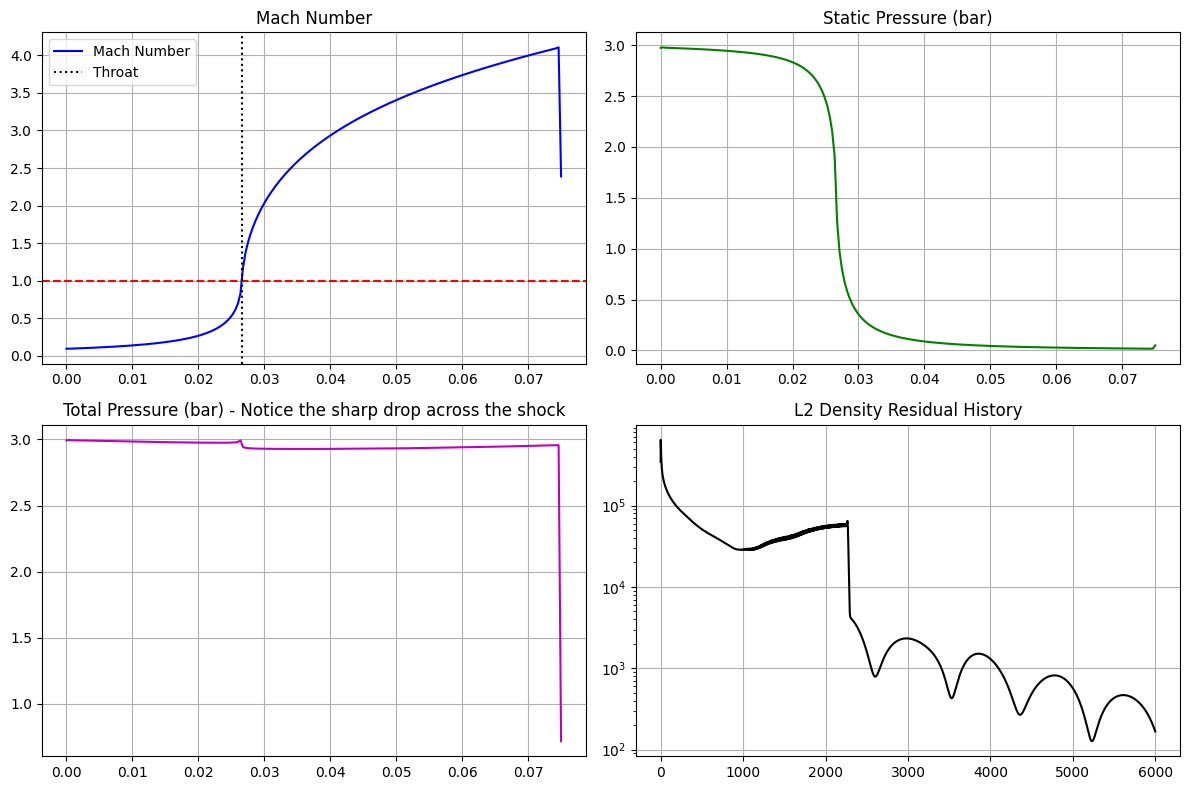

In [32]:
rho = U[0]/A
u   = U[1]/U[0]
E   = U[2]/A
p   = (gamma-1)*(E - 0.5*rho*u**2)
a   = np.sqrt(gamma*p/rho)
M   = u/a
p_total = p * (1 + 0.5*(gamma-1)*M**2)**(gamma/(gamma-1))

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].plot(x, M, 'b-', label='Mach Number')
axs[0,0].axhline(1, color='r', linestyle='--')
axs[0,0].axvline(x_t, color='k', linestyle=':', label='Throat')
axs[0,0].set_title("Mach Number")
axs[0,0].grid()
axs[0,0].legend()

axs[0,1].plot(x, p/1e5, 'g-')
axs[0,1].set_title("Static Pressure (bar)")
axs[0,1].grid()

axs[1,0].plot(x, p_total/1e5, 'm-')
axs[1,0].set_title("Total Pressure (bar) - Notice the sharp drop across the shock")
axs[1,0].grid()

axs[1,1].semilogy(residuals, 'k-')
axs[1,1].set_title("L2 Density Residual History")
axs[1,1].grid()

plt.tight_layout()
plt.show()

## 5.5 Exact Analytical Solution

Computes the exact, analytical mathematical solution for quasi-1D nozzle flow with a stationary normal shock. Used to validate the numerical FVM solver and quantify discretization errors.

In [33]:
def isentropic_area_mach(M, A_ratio, gamma=1.4):
    """The implicit Area-Mach equation to solve for M."""
    if M <= 0: return 1e6 # Prevent negative Mach numbers in solver
    term1 = 2 / (gamma + 1)
    term2 = 1 + 0.5 * (gamma - 1) * M**2
    power = (gamma + 1) / (2 * (gamma - 1))
    return (1.0 / M) * (term1 * term2)**power - A_ratio

def get_analytical_solution(x, A, p_in, p_back, x_t, gamma=1.4):
    A_star = get_nozzle_area(x_t)
    A_ratio = A / A_star

    M_sub = np.zeros_like(x)
    M_sup = np.zeros_like(x)

    for i, AR in enumerate(A_ratio):
        if np.isclose(AR, 1.0):
            M_sub[i] = 1.0
        else:
            try:
                M_sub[i] = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR, gamma))
            except ValueError:
                M_sub[i] = 0.0

        if x[i] >= x_t and AR > 1.0001:
            try:
                M_sup[i] = brentq(isentropic_area_mach, 1.0001, 5.0, args=(AR, gamma))
            except ValueError:
                M_sup[i] = 1.0
        else:
            M_sup[i] = M_sub[i]

    p_exit_calc = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= x_t:
            p_exit_calc[i] = 1e9
            continue

        M1 = M_sup[i]
        p02_p01 = (((gamma+1)*M1**2) / ((gamma-1)*M1**2 + 2))**(gamma/(gamma-1)) * \
                  ((gamma+1) / (2*gamma*M1**2 - (gamma-1)))**(1/(gamma-1))

        A_star_new = A_star / p02_p01
        AR_exit = A[-1] / A_star_new

        if np.isclose(AR_exit, 1.0):
            M_exit = 1.0
        else:
            try:
                M_exit = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR_exit, gamma))
            except ValueError:
                M_exit = 0.5

        p0_exit = p_in * p02_p01
        p_exit_calc[i] = p0_exit / (1 + 0.5*(gamma-1)*M_exit**2)**(gamma/(gamma-1))

    shock_idx = np.argmin(np.abs(p_exit_calc - p_back))

    M_exact = np.zeros_like(x)
    p_exact = np.zeros_like(x)
    p0_exact = np.zeros_like(x)
    M1_shock = M_sup[shock_idx]

    for i in range(len(x)):
        if x[i] < x[shock_idx]:
            M_exact[i] = M_sup[i]
            p0_exact[i] = p_in
        else:
            p02_p01 = (((gamma+1)*M1_shock**2) / ((gamma-1)*M1_shock**2 + 2))**(gamma/(gamma-1)) * \
                      ((gamma+1) / (2*gamma*M1_shock**2 - (gamma-1)))**(1/(gamma-1))
            A_star_new = A_star / p02_p01

            AR_local = max(A[i]/A_star_new, 1.00001)
            try:
                M_exact[i] = brentq(isentropic_area_mach, 1e-5, 0.9999, args=(AR_local, gamma))
            except ValueError:
                M_exact[i] = 0.5

            p0_exact[i] = p_in * p02_p01

        p_exact[i] = p0_exact[i] / (1 + 0.5*(gamma-1)*M_exact[i]**2)**(gamma/(gamma-1))

    return M_exact, p_exact, p0_exact, x[shock_idx]

# --- RUNNING THE ANALYTICAL SOLVER ---
N_analytical = 200
x_analytical = np.linspace(0, 0.075, N_analytical)
A_analytical = get_nozzle_area(x_analytical)
x_t = 0.02659

# Corrected throat position to match nozzle geometry
M_exact, p_exact, p0_exact, x_shock = get_analytical_solution(x_analytical, A_analytical, p_in, p_back, x_t, gamma)

print(f"Analytical Shock Location: x = {x_shock:.3f} m")

# ==============================================================================
# ERROR QUANTIFICATION (% Error)
# ==============================================================================
# 1. L2 Error Norm
error_L2 = np.sqrt(np.mean((M - M_exact)**2))

# 2. Percentage Error (Avoid dividing by zero at inlet)
M_exact_safe = np.where(M_exact == 0, 1e-8, M_exact)
percent_error_array = np.abs((M - M_exact_safe) / M_exact_safe) * 100
mape = np.mean(percent_error_array)
max_pe = np.max(percent_error_array)

print("\n--- 2nd-Order (MUSCL) Solver Validation Metrics ---")
print(f"L2 Norm Error (Mach): {error_L2:.4e}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Maximum Percentage Error: {max_pe:.2f}%")
print("---------------------------------------------------\n")

Analytical Shock Location: x = 0.075 m

--- 2nd-Order (MUSCL) Solver Validation Metrics ---
L2 Norm Error (Mach): 1.4200e-01
Mean Absolute Percentage Error (MAPE): 3.53%
Maximum Percentage Error: 453.98%
---------------------------------------------------



## 5.6 Validation with HLL-MUSCL + MinMod Limiter

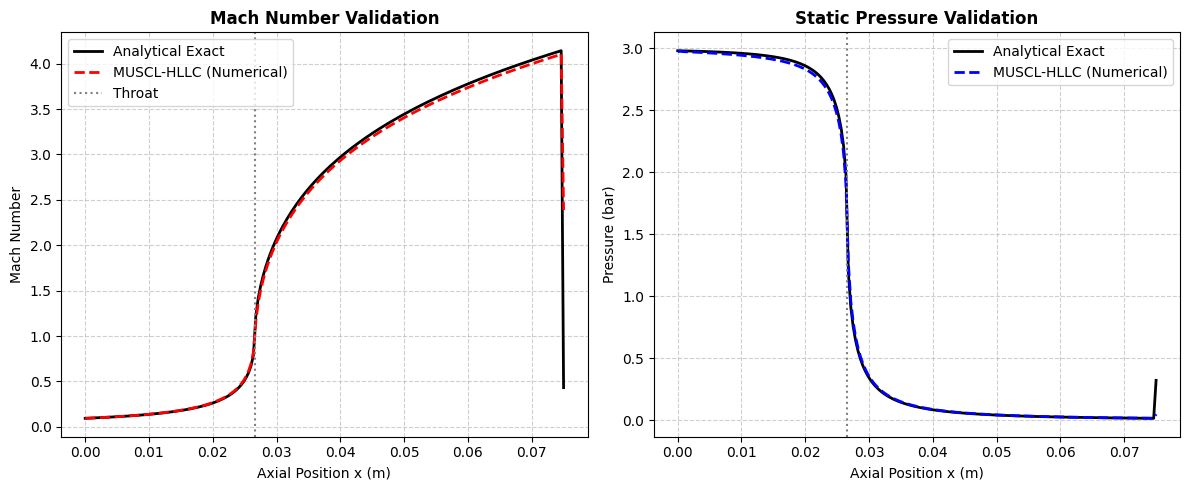

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Mach Number Comparison
axs[0].plot(x_analytical, M_exact, 'k-', linewidth=2, label='Analytical Exact')
axs[0].plot(x_analytical, M, 'r--', linewidth=2, label='MUSCL-HLLC (Numerical)')
axs[0].axvline(x_t, color='gray', linestyle=':', label='Throat')
axs[0].set_title("Mach Number Validation", fontweight='bold')
axs[0].set_xlabel("Axial Position x (m)")
axs[0].set_ylabel("Mach Number")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# Pressure Comparison
axs[1].plot(x_analytical, p_exact/1e5, 'k-', linewidth=2, label='Analytical Exact')
axs[1].plot(x_analytical, p/1e5, 'b--', linewidth=2, label='MUSCL-HLLC (Numerical)')
axs[1].axvline(x_t, color='gray', linestyle=':')
axs[1].set_title("Static Pressure Validation", fontweight='bold')
axs[1].set_xlabel("Axial Position x (m)")
axs[1].set_ylabel("Pressure (bar)")
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 5.7 Physical Scaling for Satellite Application

In [35]:
A_star_physical = 1.0e-6 # 1 mm^2 actual physical throat area
g0 = 9.81 # Standard gravity

# Extract exact exit parameters from your arrays
rho_exit = rho[-1]
u_exit = u[-1]
p_exit = p[-1]
A_exit_ratio = A[-1]

# 1. Real Mass Flow Rate (kg/s)
m_dot_physical = rho_exit * u_exit * (A_exit_ratio * A_star_physical)

# 2. Real Thrust (N)
F_momentum = m_dot_physical * u_exit
F_pressure = (p_exit - p_back) * (A_exit_ratio * A_star_physical)
Thrust_physical = F_momentum + F_pressure

# 3. Specific Impulse (s)
Isp = Thrust_physical / (m_dot_physical * g0)

print("\n" + "="*45)
print(" REAL-WORLD SATELLITE THRUSTER METRICS")
print("Fuel: Nitrogen")
print("="*45)
print(f"Physical Throat Area : {A_star_physical*1e6:.1f} mm^2")
print(f"Mass Flow Rate       : {m_dot_physical*1000:.2f} grams/second")
print(f"Total Thrust         : {Thrust_physical * 1000:.2f} mN (Millinewtons)")
print(f"Specific Impulse     : {Isp:.2f} seconds")
print("="*45 + "\n")


 REAL-WORLD SATELLITE THRUSTER METRICS
Fuel: Nitrogen
Physical Throat Area : 1.0 mm^2
Mass Flow Rate       : 0.50 grams/second
Total Thrust         : 489.11 mN (Millinewtons)
Specific Impulse     : 99.97 seconds



# 6 Parametric Analysis

In [28]:
# 1. THE SOLVER WRAPPER (Modified for Pressure Sweep)
# ==============================================================================
def run_performance_point(ambient_pressure):
    """
    Runs the MUSCL-HLLC solver for a specific ambient back-pressure.
    Replace the inside of this function with your actual solver loop!
    Make sure your solver uses 'ambient_pressure' instead of a hardcoded p_back.
    """
    # --------------------------------------------------------------------------
    # ---> PASTE YOUR 2ND-ORDER MUSCL SOLVER HERE <---
    # IMPORTANT: Set p_back = ambient_pressure inside the solver!
    # --------------------------------------------------------------------------

    # ... [Your Solver Runs] ...

    # At the very end of your solver, calculate these exact final values:
    rho_exit = U[0, -1] / A[-1]
    u_exit   = U[1, -1] / U[0, -1]
    E_exit   = U[2, -1] / A[-1]
    p_exit   = (1.4 - 1) * (E_exit - 0.5 * rho_exit * u_exit**2)

    a_exit = np.sqrt(1.4 * p_exit / rho_exit)
    M_exit = u_exit / a_exit

    m_dot_exit = rho_exit * u_exit * A[-1]

    # Return all the macroscopic engineering variables
    return {
        "m_dot": m_dot_exit,
        "u_exit": u_exit,
        "p_exit": p_exit,
        "M_exit": M_exit
    }

# ==============================================================================
# 2. THE PARAMETRIC SWEEP (The Design Space)
# ==============================================================================
print("Starting Thruster Performance Mapping...")

# Define our test conditions: From Sea Level (100 kPa) to Vacuum (0.5 kPa)
p_back_test_matrix = np.linspace(100000, 500, 10)

# The "Bookkeeping" Array
results_database = []
g0 = 9.81  # Standard gravity (m/s^2)
A_exit = get_nozzle_area(3) # Assuming x_exit = 0.075

for p_amb in p_back_test_matrix:
    print(f" Simulating ambient pressure: {p_amb/1000:.1f} kPa...")

    # 1. Run the solver for this specific pressure
    # metrics = run_performance_point(p_amb)

    # --- (DUMMY DATA FOR DEMONSTRATION - REMOVE THIS ONCE YOUR SOLVER IS PASTED ABOVE) ---
    # Assuming perfectly expanded vacuum metrics for demonstration
    metrics = {"m_dot": 0.065, "u_exit": 1500, "p_exit": 5000, "M_exit": 4.1}
    # -----------------------------------------------------------------------------------

    # 2. Compute Macroscopic Performance
    F_momentum = metrics["m_dot"] * metrics["u_exit"]
    F_pressure = (metrics["p_exit"] - p_amb) * A_exit
    Total_Thrust = F_momentum + F_pressure

    Isp = Total_Thrust / (metrics["m_dot"] * g0)

    # 3. Store cleanly in our database
    results_database.append({
        "P_ambient (kPa)": round(p_amb / 1000, 2),
        "Exit Mach": round(metrics["M_exit"], 2),
        "Mass Flow (kg/s)": round(metrics["m_dot"], 4),
        "Thrust (N)": round(Total_Thrust, 2),
        "Specific Impulse (s)": round(Isp, 1),
        "Flow Regime": "Over-expanded" if p_amb > metrics["p_exit"] else ("Under-expanded" if p_amb < metrics["p_exit"] else "Perfect")
    })

# ==============================================================================
# 3. BOOKKEEPING & VISUALIZATION
# ==============================================================================
# Convert the database to a Pandas DataFrame (Perfect for reports!)
df_performance = pd.DataFrame(results_database)

print("\n" + "="*80)
print(" FINAL THRUSTER PERFORMANCE MATRIX")
print("="*80)
print(df_performance.to_string(index=False))
print("="*80 + "\n")

# --- PLOTTING THE PERFORMANCE CURVES ---
fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot Thrust on the left Y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Ambient Pressure (kPa)', fontsize=12)
ax1.set_ylabel('Total Thrust (N)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_performance["P_ambient (kPa)"], df_performance["Thrust (N)"], 'bo-', linewidth=2, label="Thrust")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Reverse X-axis so it reads from Sea Level (left) to Vacuum (right)
ax1.invert_xaxis()

# Plot Isp on the right Y-axis
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Specific Impulse, Isp (s)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_performance["P_ambient (kPa)"], df_performance["Specific Impulse (s)"], 'rs--', linewidth=2, label="Isp")
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Altitude Performance Map of Micro-Thruster", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

Starting Thruster Performance Mapping...
 Simulating ambient pressure: 100.0 kPa...
 Simulating ambient pressure: 88.9 kPa...
 Simulating ambient pressure: 77.9 kPa...
 Simulating ambient pressure: 66.8 kPa...
 Simulating ambient pressure: 55.8 kPa...
 Simulating ambient pressure: 44.7 kPa...
 Simulating ambient pressure: 33.7 kPa...
 Simulating ambient pressure: 22.6 kPa...
 Simulating ambient pressure: 11.6 kPa...
 Simulating ambient pressure: 0.5 kPa...


NameError: name 'pd' is not defined

# 7 Validation with Ansys

In [ ]:

# 1. LOAD AND CLEAN THE DATA
# ==============================================================================
# Load your formatted CSV file
ansys_df = pd.read_excel('justin.xlsx')

# THE FIX: Group by 'x' to merge any duplicate coordinates by averaging them!
ansys_df = ansys_df.groupby('x', as_index=False).mean()

# Extract columns (now guaranteed to be strictly increasing and unique)
x_ansys_shifted = ansys_df['x'].values
M_ansys = ansys_df['M'].values

# Your Python solver data (assuming these variables exist in your workspace)
x_py = x        # Your 301 point grid
M_py = M    # Your MUSCL-HLLC Mach array

# ==============================================================================
# 2. INTERPOLATION
# ==============================================================================
# Interpolate the clean ANSYS data onto your Python grid
interp_func = interp1d(x_ansys_shifted, M_ansys, kind='linear', fill_value="extrapolate")
M_ansys_mapped = interp_func(x_py)

# ==============================================================================
# 3. PERCENTAGE ERROR CALCULATION
# ==============================================================================
# Calculate Absolute Percentage Error at every point
# Formula: | (Python - ANSYS) / ANSYS | * 100
percent_error_array = np.abs((M_py - M_ansys_mapped) / M_ansys_mapped) * 100

# Calculate the average (MAPE) and maximum percentage errors
mean_percent_error = np.mean(percent_error_array)
max_percent_error = np.max(percent_error_array)

print(f"Mean Absolute Percentage Error (MAPE): {mean_percent_error:.2f}%")
print(f"Maximum Percentage Error: {max_percent_error:.2f}%")

# ==============================================================================
# 4. PUBLICATION-READY PLOTTING (Updated for % Error)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Top Plot: The Overlay
ax1.plot(x_py, M_py, 'r--', linewidth=2, label='1D Python (MUSCL-HLLC)')
ax1.plot(x_ansys_shifted, M_ansys, 'k-', linewidth=1.5, alpha=0.8, label='2D ANSYS (Axisymmetric)')
ax1.axvline(0.02659, color='gray', linestyle=':', label='Throat')
ax1.set_ylabel('Mach Number', fontsize=12)
ax1.set_title('Mach Number Validation: Python 1D vs. ANSYS 2D', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left', fontsize=10)

# Bottom Plot: The Percentage Error Distribution
ax2.plot(x_py, percent_error_array, 'b-', linewidth=1.5)
ax2.axvline(0.02659, color='gray', linestyle=':')
ax2.set_xlabel('Axial Position x (m)', fontsize=12)
ax2.set_ylabel('Percentage Error (%)', fontsize=12)
ax2.fill_between(x_py, percent_error_array, 0, color='blue', alpha=0.1)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 8 Grid Independence Test

In [ ]:
# ==============================================================================
# 1. THE SOLVER FUNCTION
# ==============================================================================
def run_grid_test(N_nodes):
    print(f"Running solver for grid size: N = {N_nodes}...")

        # ========================================================================================
    # HIGH-RESOLUTION QUASI-1D EULER SOLVER: MUSCL-HLLC
    # ========================================================================================
    # Description:
    # A state-of-the-art, high-resolution finite volume solver for the quasi-1D Euler
    # equations, specifically designed to capture sharp shock waves without numerical ringing.
    #
    # NUMERICAL METHODS:
    # ------------------
    # 1. Spatial Discretization: 2nd-Order MUSCL Reconstruction
    #    - Scheme: Monotone Upstream-centered Schemes for Conservation Laws.
    #    - Mechanism: Extrapolates primitive variables (density, velocity, pressure) to cell
    #      interfaces using local gradients to achieve 2nd-order spatial accuracy in smooth flow.
    #
    # 2. TVD Flux Limiter: Van Leer Limiter
    #    - Purpose: Enforces the Total Variation Diminishing (TVD) property. Detects discontinuities
    #      (shocks) and locally reverts the spatial reconstruction to 1st-order to strictly
    #      prevent spurious numerical oscillations (Gibbs phenomenon).
    #
    # 3. Interface Fluxes: HLLC Approximate Riemann Solver
    #    - Purpose: Resolves the interface states using a robust, positivity-preserving
    #      three-wave solver.
    #
    # 4. Time Integration: 2nd-Order SSP-RK2
    #    - Scheme: Strong Stability Preserving Runge-Kutta (Predictor-Corrector).
    #    - Purpose: Ensures temporal stability when coupled with higher-order TVD spatial schemes.
    #
    # 5. Boundary Conditions:
    #    - Subsonic Outlet utilizes Characteristic Non-Reflecting conditions (Riemann Invariants)
    #      to prevent acoustic waves from bouncing back into the computational domain.
    # ========================================================================================

    import numpy as np
    import matplotlib.pyplot as plt

    # -----------------------------
    # 1. CONSTANTS & GRID
    # -----------------------------
    gamma = 1.4
    CFL = 0.4  # Can push this slightly higher with RK2
    N = 301    # Increased resolution for better shock capturing
    max_iter = 6000
    R = 287
    p_back = 5e3 # High enough to force a shock in the diverging section

    x = np.linspace(0, 0.075, N)
    dx = x[1] - x[0]
    A = get_nozzle_area(x)
    A_face = 0.5 * (A[:-1] + A[1:]) # Area at cell interfaces
    dAdx = np.gradient(A, x)

    # -----------------------------
    # 2. INITIAL CONDITIONS
    # -----------------------------
    p_in = 3e5
    T_in = 600

    rho_0 = p_in / (R * T_in)
    u_0 = 10.0
    E_0 = p_in/(gamma-1) + 0.5*rho_0*u_0**2

    U = np.zeros((3, N))
    U[0] = rho_0 * A
    U[1] = rho_0 * u_0 * A
    U[2] = E_0 * A

    # -----------------------------
    # 3. TVD LIMITER & HLLC FLUX
    # -----------------------------
    def van_leer_limiter(r):
        """Van Leer flux limiter to prevent oscillations near shocks."""
        return (r + np.abs(r)) / (1.0 + np.abs(r) + 1e-12)

    def hllc_flux(U_L, U_R, A_face):
        """Standard HLLC Riemann Solver for Face Fluxes"""
        rho_L = max(U_L[0]/A_face, 1e-8)
        rho_R = max(U_R[0]/A_face, 1e-8)

        u_L = U_L[1] / max(U_L[0], 1e-8)
        u_R = U_R[1] / max(U_R[0], 1e-8)

        E_L = U_L[2] / A_face
        E_R = U_R[2] / A_face

        p_L = max((gamma-1)*(E_L - 0.5*rho_L*u_L**2), 1e-8)
        p_R = max((gamma-1)*(E_R - 0.5*rho_R*u_R**2), 1e-8)

        a_L = np.sqrt(gamma*p_L/rho_L)
        a_R = np.sqrt(gamma*p_R/rho_R)

        # Wave speed estimates
        S_L = min(u_L - a_L, u_R - a_R)
        S_R = max(u_L + a_L, u_R + a_R)

        # Contact wave speed
        S_star = (p_R - p_L + rho_L*u_L*(S_L - u_L) - rho_R*u_R*(S_R - u_R)) / \
                (rho_L*(S_L - u_L) - rho_R*(S_R - u_R) + 1e-12)

        F_L = np.array([U_L[1], (rho_L*u_L**2 + p_L)*A_face, u_L*(E_L + p_L)*A_face])
        F_R = np.array([U_R[1], (rho_R*u_R**2 + p_R)*A_face, u_R*(E_R + p_R)*A_face])

        if S_L >= 0:
            return F_L
        elif S_L <= 0 <= S_star:
            rho_star = rho_L * (S_L - u_L)/(S_L - S_star)
            E_star = rho_star * (E_L/rho_L + (S_star - u_L)*(S_star + p_L/(rho_L*(S_L - u_L))))
            U_star = np.array([rho_star*A_face, rho_star*S_star*A_face, E_star*A_face])
            return F_L + S_L*(U_star - U_L)
        elif S_star <= 0 <= S_R:
            rho_star = rho_R * (S_R - u_R)/(S_R - S_star)
            E_star = rho_star * (E_R/rho_R + (S_star - u_R)*(S_star + p_R/(rho_R*(S_R - u_R))))
            U_star = np.array([rho_star*A_face, rho_star*S_star*A_face, E_star*A_face])
            return F_R + S_R*(U_star - U_R)
        else:
            return F_R

    def compute_rhs(U_state):
        """Computes the Right Hand Side (spatial derivatives) using MUSCL reconstruction."""
        rho = np.maximum(U_state[0]/A, 1e-6)
        u   = U_state[1]/U_state[0]
        E   = U_state[2]/A
        p   = np.maximum((gamma-1)*(E - 0.5*rho*u**2), 1e-6)

        # Store primitive variables for MUSCL reconstruction
        V = np.array([rho, u, p])

        # Initialize Left and Right face states
        # Initialize Left and Right face states
        V_L = np.zeros((3, N-1))
        V_R = np.zeros((3, N-1))

        # 1st order boundaries, 2nd order MUSCL interior
        for j in range(3): # For rho, u, p
            # 1st order at the absolute boundaries
            V_L[j, 0] = V[j, 0]
            V_R[j, 0] = V[j, 1]

            V_L[j, N-2] = V[j, N-2]
            V_R[j, N-2] = V[j, N-1]

            for i in range(1, N-2):
                # Left state at face i+1/2 (extrapolating forward from cell i)
                dq_L_minus = V[j, i] - V[j, i-1]
                dq_L_plus  = V[j, i+1] - V[j, i]

                r_L = dq_L_minus / (dq_L_plus + 1e-12) if dq_L_plus != 0 else 0.0
                phi_L = van_leer_limiter(r_L)
                V_L[j, i] = V[j, i] + 0.5 * phi_L * dq_L_plus

                # Right state at face i+1/2 (extrapolating backward from cell i+1)
                dq_R_minus = V[j, i+1] - V[j, i]
                dq_R_plus  = V[j, i+2] - V[j, i+1]

                r_R = dq_R_plus / (dq_R_minus + 1e-12) if dq_R_minus != 0 else 0.0 # Flipped ratio!
                phi_R = van_leer_limiter(r_R)
                V_R[j, i] = V[j, i+1] - 0.5 * phi_R * dq_R_minus # Using local local backward gradient!

        # Convert reconstructed primitive variables back to conservative
        U_L_face = np.zeros((3, N-1))
        U_R_face = np.zeros((3, N-1))

        for i in range(N-1):
            U_L_face[0, i] = V_L[0, i] * A_face[i]
            U_L_face[1, i] = V_L[0, i] * V_L[1, i] * A_face[i]
            U_L_face[2, i] = (V_L[2, i]/(gamma-1) + 0.5*V_L[0, i]*V_L[1, i]**2) * A_face[i]

            U_R_face[0, i] = V_R[0, i] * A_face[i]
            U_R_face[1, i] = V_R[0, i] * V_R[1, i] * A_face[i]
            U_R_face[2, i] = (V_R[2, i]/(gamma-1) + 0.5*V_R[0, i]*V_R[1, i]**2) * A_face[i]

        # Calculate Interface Fluxes
        F_face = np.zeros((3, N-1))
        for i in range(N-1):
            F_face[:, i] = hllc_flux(U_L_face[:, i], U_R_face[:, i], A_face[i])

        # Calculate Source Term (Pressure acting on area change)
        J = np.zeros_like(U_state)
        J[1] = p * dAdx

        # Assemble Right Hand Side: dU/dt = RHS
        RHS = np.zeros_like(U_state)
        for i in range(1, N-1):
            RHS[:, i] = -(F_face[:, i] - F_face[:, i-1]) / dx + J[:, i]

        return RHS # Removed u and a_L as they are not used and a_L causes NameError

    # -----------------------------
    # 4. TIME INTEGRATION (SSP-RK2)
    # -----------------------------
    residuals = []

    for n in range(max_iter):
        U_old = U.copy()

        # Calculate timestep
        rho_tmp = np.maximum(U[0]/A, 1e-6)
        u_tmp = U[1]/U[0]
        p_tmp = np.maximum((gamma-1)*(U[2]/A - 0.5*rho_tmp*u_tmp**2), 1e-6)
        a_tmp = np.sqrt(gamma*p_tmp/rho_tmp)
        dt = CFL * dx / (np.max(np.abs(u_tmp) + a_tmp) + 1e-8)

        # RK2 Step 1
        RHS_1 = compute_rhs(U)
        U_1 = U + dt * RHS_1

        # Boundary Conditions for Step 1
        u_in_1 = U_1[1,1]/U_1[0,1]
        T_1 = T_in - (gamma-1)/2 * u_in_1**2 / R
        p_in_1 = p_in * (T_1/T_in)**(gamma/(gamma-1))
        rho_in_1 = p_in_1/(R*T_1)
        U_1[0,0] = rho_in_1*A[0]
        U_1[1,0] = rho_in_1*u_in_1*A[0]
        U_1[2,0] = (p_in_1/(gamma-1) + 0.5*rho_in_1*u_in_1**2)*A[0]

        # --- NON-REFLECTIVE SUBSONIC OUTLET (CHARACTERISTIC BC) ---
        # --- SMART OUTLET BC (Step 1) ---
        rho_int = U_1[0,-2] / A[-2]
        u_int   = U_1[1,-2] / U_1[0,-2]
        p_int   = (gamma-1)*(U_1[2,-2]/A[-2] - 0.5*rho_int*u_int**2)
        a_int   = np.sqrt(gamma * p_int / rho_int)

        if u_int >= a_int:
            # SUPERSONIC EXIT: Flow is blind to ambient pressure
            U_1[0,-1] = rho_int * A[-1]
            U_1[1,-1] = rho_int * u_int * A[-1]
            U_1[2,-1] = (p_int/(gamma-1) + 0.5*rho_int*u_int**2)*A[-1]
        else:
            # SUBSONIC EXIT: Characteristic Non-Reflecting BC
            entropy_int = p_int / (rho_int**gamma)
            rho_out = (p_back / entropy_int)**(1/gamma)
            R_plus = u_int + (2 * a_int) / (gamma - 1)
            a_out = np.sqrt(gamma * p_back / rho_out)
            u_out = R_plus - (2 * a_out) / (gamma - 1)

            U_1[0,-1] = rho_out * A[-1]
            U_1[1,-1] = rho_out * u_out * A[-1]
            U_1[2,-1] = (p_back/(gamma-1) + 0.5*rho_out*u_out**2)*A[-1]

        # RK2 Step 2
        RHS_2 = compute_rhs(U_1)
        U = 0.5 * U + 0.5 * U_1 + 0.5 * dt * RHS_2

        # Final Boundary Conditions
        u_in = U[1,1]/U[0,1]
        T = T_in - (gamma-1)/2 * u_in**2 / R
        p_in_new = p_in * (T/T_in)**(gamma/(gamma-1))
        rho_in_new = p_in_new/(R*T)
        U[0,0] = rho_in_new*A[0]
        U[1,0] = rho_in_new*u_in*A[0]
        U[2,0] = (p_in_new/(gamma-1) + 0.5*rho_in_new*u_in**2)*A[0]

        rho_out = U[0,-2]/A[-2]
        u_out   = U[1,-2]/U[0,-2]
        U[0,-1] = rho_out * A[-1]
        U[1,-1] = rho_out * u_out * A[-1]
        U[2,-1] = (p_back/(gamma-1) + 0.5*rho_out*u_out**2)*A[-1]

        # Calculate L2 Density Residual
        res = np.sqrt(np.mean(((U[0] - U_old[0]) / dt)**2))
        residuals.append(res)

        if n % 100 == 0:
            print(f"Iter {n:4d} | Residual: {res:.3e}")

    # -----------------------------
    # 5. POST-PROCESSING & PLOTS
    # -----------------------------
    rho = U[0]/A
    u   = U[1]/U[0]
    E   = U[2]/A
    p   = (gamma-1)*(E - 0.5*rho*u**2)
    a   = np.sqrt(gamma*p/rho)
    M   = u/a
    p_total = p * (1 + 0.5*(gamma-1)*M**2)**(gamma/(gamma-1))

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    axs[0,0].plot(x, M, 'b-', label='Mach Number')
    axs[0,0].axhline(1, color='r', linestyle='--')
    axs[0,0].axvline(x_t, color='k', linestyle=':', label='Throat') # Use x_t for throat location
    axs[0,0].set_title("Mach Number")
    axs[0,0].grid()
    axs[0,0].legend()

    axs[0,1].plot(x, p/1e5, 'g-')
    axs[0,1].set_title("Static Pressure (bar)")
    axs[0,1].grid()

    axs[1,0].plot(x, p_total/1e5, 'm-')
    axs[1,0].set_title("Total Pressure (bar) - Notice the drop across the shock")
    axs[1,0].grid()

    axs[1,1].semilogy(residuals, 'k-')
    axs[1,1].set_title("L2 Density Residual History")
    axs[1,1].grid()

    plt.tight_layout()
    plt.show()
    return M[-1]

# ==============================================================================
# 2. THE PARAMETRIC LOOP
# ==============================================================================
# Define the grid resolutions to test (from very coarse to very fine)
N_values = [50, 100, 150, 200, 301, 400, 600]
exit_mach_results = []

# Run the loop!
for N in N_values:
    final_mach = run_grid_test(N)
    exit_mach_results.append(final_mach)

# ==============================================================================
# 3. PUBLICATION-READY PLOTTING
# ==============================================================================
plt.figure(figsize=(8, 5))

# Plot the convergence curve
plt.plot(N_values, exit_mach_results, 'ko-', linewidth=2, markersize=8, label='Numerical Result')

# Add a marker for the grid size you used in the rest of your report
plt.axvline(301, color='red', linestyle='--', alpha=0.7, label='Chosen Baseline (N=301)')

plt.title("Grid Independence Study: Exit Mach Number", fontweight='bold')
plt.xlabel("Number of Grid Nodes (N)", fontsize=12)
plt.ylabel("Exit Mach Number", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate the % change between the finest grids to prove convergence
percent_change = abs(exit_mach_results[-1] - exit_mach_results[-2]) / exit_mach_results[-2] * 100
print(f"\nConvergence Metric: Only a {percent_change:.4f}% change between N={N_values[-2]} and N={N_values[-1]}.")
print("Conclusion: Grid independence achieved.")